## 📦 Install Required Packages

In [124]:
# %pip install kagglehub numpy pandas matplotlib seaborn plotly ydata-profiling sweetviz dtale dash autoviz mysql-connector-python sqlite 
# if using anaconda environment, open the terminal, activate the environment, and then use the following command instead:
# conda install -c conda-forge kagglehub numpy pandas matplotlib seaborn plotly ydata-profiling sweetviz dtale dash autoviz mysql-connector-python sqlite 


# 📚 NumPy, Pandas, MySQL & EDA — Integrated Lecture Notebook

This single notebook integrates **Python recap**, **NumPy**, **Pandas**, **EDA (manual + automatic)**, and **SQL** in a logical order.



## Table of Contents
- [Python Recap](#python-recap)
- [Environment Check & Imports](#env)
- [NumPy Deep Dive](#numpy)
- [Pandas Essentials](#pandas)
- [Manual EDA](#eda-manual)
- [Automatic EDA](#eda-auto)
- [SQL in the Workflow](#sql)
- [Integration Project](#integration)
- [Wrap-up](#wrapup)


<a id="python-recap"></a>

# Python Recap

<a id="env"></a>

#### Environment Check & Imports


In [125]:
import sys, platform

print("Python:", sys.version.split()[0])
print("Platform:", platform.platform())


Python: 3.13.9
Platform: Windows-11-10.0.26200-SP0


In [126]:
# Core scientific stack
import numpy as np
import pandas as pd

# Viz (use matplotlib as base; seaborn optional)
import matplotlib.pyplot as plt

print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)


NumPy: 2.3.5
Pandas: 2.3.3


## Collections

### List

In [127]:
basket_list = ['apple', 'orange', 'pear', 'pear', 'orange', 'banana']
print(basket_list)

['apple', 'orange', 'pear', 'pear', 'orange', 'banana']


In [128]:
basket_list[0] = 'pear'

In [129]:
basket_list

['pear', 'orange', 'pear', 'pear', 'orange', 'banana']

In [130]:
print(set(basket_list))

{'pear', 'banana', 'orange'}


In [131]:
basket_list = ['apple', 2, 'apple', 4.5,'orange', 'banana']
print(basket_list)

['apple', 2, 'apple', 4.5, 'orange', 'banana']


### Set

In [132]:
basket_set = ['apple', 'orange', 'apple', 'pear', 'orange', 'banana']
# set(basket_list)
print(basket_set)

['apple', 'orange', 'apple', 'pear', 'orange', 'banana']


In [133]:
set(basket_set)

{'apple', 'banana', 'orange', 'pear'}

In [134]:
tuple(basket_set)

('apple', 'orange', 'apple', 'pear', 'orange', 'banana')

### Tuples

In [135]:
t = (12345, 54321, 'hello!')
print(t[0])

12345


In [136]:
t=list(t)

In [137]:
t[0]=12

In [138]:
tuple(t)

(12, 54321, 'hello!')

t[0] = 12
---------------------------------------------------------------------------
TypeError                                 Traceback (most recent call last)
Cell In[5], line 1
----> 1 t[0] = 12

TypeError: 'tuple' object does not support item assignment



### Dctionary

In [139]:
tel = {'jack': 4098, 'sape': 4139}
tel['guido'] = 4127
print(tel)

{'jack': 4098, 'sape': 4139, 'guido': 4127}


## Python concepts – Memory Allocation

### Immutable Objects

In [140]:
a = 3

In [141]:
b = 3

In [142]:
print(id(a))

140704750478312


In [143]:
print(id(b))

140704750478312


In [144]:
print('a = ',a)
print('b = ',b)

a =  3
b =  3


Yes, in Python, a = 3 and b = 3 typically point to the same memory location (object) due to an optimization called integer interning. 

Explanation
Variables as References:
In Python, variables are not memory boxes storing the value itself, but rather labels or references pointing to objects in memory.
Integer Interning: The default Python implementation (CPython) pre-caches or "interns" small integers, usually in the range of -5 to 256, to optimize memory usage and speed. When you create a new variable with a value within this range, Python simply reuses the existing object in memory instead of creating a new one.
Verification with is and id():
The is operator checks if two variables point to the exact same object in memory.
The id() function returns a unique identifier (memory address) for an object. 


In [145]:
print(a is b)
# Output: True

print(id(a) == id(b))
# Output: True

True
True


Contrast with Larger Integers. 
For integers outside the cached range (e.g., 300), Python is not guaranteed to reuse the memory location, so is might return False: 

In [146]:
c = 300
d = 300

print(c is d)
# Output: False

False


It is important to remember that is checks for identity (same memory location), while == checks for value equality. You should always use == for comparing values unless you specifically need to know if they are the same object in memory.

In [147]:
a = 4
b = 3

In [148]:
print(id(a))

140704750478344


In [149]:
print(id(b))

140704750478312


In [150]:
print('a = ',a)
print('b = ',b)

a =  4
b =  3


In [151]:
b=5

In [152]:
print(id(b))

140704750478376


### Mutable Objects

In [153]:
a = [1,2,3]
b = a
print('a = ', a)
print('b = ', b)
b[0] = 'NewValue'  # what is happening here?
print('a = ', a)
print('b = ', b)
print(id(a))
print(id(b))

a =  [1, 2, 3]
b =  [1, 2, 3]
a =  ['NewValue', 2, 3]
b =  ['NewValue', 2, 3]
2025889535360
2025889535360


In [154]:
a = [1,2,3]
b = a
print('a = ', a)
print('b = ', b)
b = ['NewValue', 2, 3] # what is happening here?
print('a = ', a)
print('b = ', b)
print(id(a))
print(id(b))

a =  [1, 2, 3]
b =  [1, 2, 3]
a =  [1, 2, 3]
b =  ['NewValue', 2, 3]
2025931445824
2025931444032


### Python – list comprehension 

In [155]:
squares = []
for x in range(10):
    squares.append(x**2)
print(squares)

[0, 1, 4, 9, 16, 25, 36, 49, 64, 81]


In [156]:
squares = [x**2 for x in range(10)]
print(squares)

[0, 1, 4, 9, 16, 25, 36, 49, 64, 81]


### Function definitions and use

In [157]:
def sqr(x):
    s = x**2
    return s

In [158]:
print(sqr(2))

4


### Strings

In [159]:
s = "d\"r Zvi ben ami"

In [160]:
s

'd"r Zvi ben ami'

In [161]:
s.replace('e','r')

'd"r Zvi brn ami'

In [162]:
print(s*2)

d"r Zvi ben amid"r Zvi ben ami


In [163]:
print(s+s)

d"r Zvi ben amid"r Zvi ben ami


In [164]:
print('single quotes allows embedded double quotes: "a" ')
print("double quotes allows embedded single quotes: 'a' ")
print("""
      Three double quotes
      allows spanning multiple lines
      with embedded single quotes: '''a''' """) 
print('''
      Three single 
      quotes allows multiple lines
      with embedded double quotes: """a""" ''')

single quotes allows embedded double quotes: "a" 
double quotes allows embedded single quotes: 'a' 

      Three double quotes
      allows spanning multiple lines
      with embedded single quotes: '''a''' 

      Three single 
      quotes allows multiple lines
      with embedded double quotes: """a""" 


### Special characters

In [165]:
print("tab\tsign, \nnewline")

tab	sign, 
newline


### Raw string

In [166]:
print(r"C:\Users\zvi.b\Documents\Zvi\HUJI\Data Science 2024\Code\1. python_recap")

C:\Users\zvi.b\Documents\Zvi\HUJI\Data Science 2024\Code\1. python_recap


### Formated string

In [167]:
name = "Alice"
age = 25
greeting = f"My name is {name} and I am {age} years old."
print(greeting)

My name is Alice and I am 25 years old.


### String with input params

In [168]:
user = "zvi"
user1 ='ben'
print(f"user name {user} and bla bla {user1}")
print("user name {}".format(user))

user name zvi and bla bla ben
user name zvi


### Strings – concatenate iterable

In [169]:
s= (" ".join(['a', 'b', 'c']))

In [170]:
s

'a b c'

In [171]:
s.split()

['a', 'b', 'c']

### Strings – other methods

In [172]:
s = "Python is fun"
print(s.lower())
print(s.upper())
print("th" in s)
print(s.replace("fun", "great"))
print(s.split(sep='None', maxsplit=1)) # try also 2
s.lower() # has s changed?
print(s)
s = s.lower() # has s changed?
print(s)

python is fun
PYTHON IS FUN
True
Python is great
['Python is fun']
Python is fun
python is fun



<a id="numpy"></a>

## NumPy Overview

**Goals:**  
- Understand arrays vs. lists, broadcasting, vectorization, and basic linear algebra.


In [173]:

# Arrays vs Lists: quick speed comparison (conceptual)
import time
import numpy as np

lst = list(range(30_000_000))  # can be smaller to keep runtime quick in class
arr = np.array(lst)

t0 = time.time()
_ = sum(lst)
t_list = time.time() - t0

t0 = time.time()
_ = arr.sum()
t_np = time.time() - t0

print(f"Sum Python list: {t_list:.6f}s  |  Sum NumPy array: {t_np:.6f}s")
if t_np > 0:
    print(f"NumPy is {t_list/t_np:.2f}x faster than Python list for summation.")


Sum Python list: 0.154441s  |  Sum NumPy array: 0.016757s
NumPy is 9.22x faster than Python list for summation.


In [174]:

# Array creation
print(np.array([1,2,3]))
print(np.arange(0, 20, 2))
print(np.linspace(0, 1, 6))
print(np.zeros((2,3)))
print(np.random.randint(1, 10, (3,3)))


[1 2 3]
[ 0  2  4  6  8 10 12 14 16 18]
[0.  0.2 0.4 0.6 0.8 1. ]
[[0. 0. 0.]
 [0. 0. 0.]]
[[3 1 8]
 [9 8 8]
 [3 4 7]]


In [175]:

# Indexing, slicing, boolean masks
arr = np.arange(10)               # [0..9]
print("slice 2:6 ->", arr[2:6])
print("even numbers ->", arr[arr % 2 == 0]) # why is it working?

# lest see what arr % 2 == 0 does:
print(arr % 2 == 0)

# so what is this?
print(arr > 4  )


slice 2:6 -> [2 3 4 5]
even numbers -> [0 2 4 6 8]
[ True False  True False  True False  True False  True False]
[False False False False False  True  True  True  True  True]


In [176]:

# Broadcasting example
sales = np.array([[10,20,30],
                  [5,15,25]])
discount = np.array([0.9, 0.8, 0.95])   # per column
print("Sales * discount ->\n", sales * discount) # how can we multiply a 2x3 array with a 1D array of length 3?
# note: this is not matrix multiplication!, but element-wise multiplication with broadcasting.
# The discount array is broadcasted across the rows of the sales array.


Sales * discount ->
 [[ 9.   16.   28.5 ]
 [ 4.5  12.   23.75]]


In [177]:
# array shape
arr = np.array([[1, 2, 3, 4], [5, 6, 7, 8]])

print(arr.shape) 

(2, 4)


In [178]:
# Reshape 
# Convert the following 1-D array with 15 elements into a 3-D array.
arr = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15])
print(arr)

newarr = arr.reshape(5, 3)
print(newarr) 

[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15]
[[ 1  2  3]
 [ 4  5  6]
 [ 7  8  9]
 [10 11 12]
 [13 14 15]]


In [179]:
print(newarr.T) # what is this .T doing?

[[ 1  4  7 10 13]
 [ 2  5  8 11 14]
 [ 3  6  9 12 15]]


In [180]:
# Array creation
print(np.array([1,2,3]))
print(np.arange(0, 10, 2))
print(np.linspace(0, 1, 5))
print(np.zeros((2,3)))
print(np.random.randint(1, 10, (3,3)))

[1 2 3]
[0 2 4 6 8]
[0.   0.25 0.5  0.75 1.  ]
[[0. 0. 0.]
 [0. 0. 0.]]
[[2 1 8]
 [8 9 5]
 [8 6 3]]


In [181]:
arr1=np.array([1,2,3])
arr2=np.array([3,2,3])
subtract_arr = np.subtract(arr1, arr2)
print('Subtract arrays', subtract_arr) 

multiply_arr = np.multiply(arr1, arr2)
print('Multiply arrays', multiply_arr) 

divide_arr = np.divide(arr1, arr2)
print('Divide arrays', divide_arr) 

power_arr = np.power(arr1, arr2)
print('Power arrays', power_arr) 

prod_arr = np.prod([arr1, arr2])
print('Product of arrays', prod_arr) # this is the product of all elements in both arrays, not element-wise product.

# product of single array
arr = np.array([1, 2, 3, 4])
x_prod_array = np.prod(arr)
print('Product of single array', x_prod_array) 

Subtract arrays [-2  0  0]
Multiply arrays [3 4 9]
Divide arrays [0.33333333 1.         1.        ]
Power arrays [ 1  4 27]
Product of arrays 108
Product of single array 24



<a id="pandas"></a>

## Pandas Essentials

**Goals:**  
- Create/load DataFrames, inspect, select, group & merge, time series basics.


### Pandas Series

In [182]:
import numpy as np
import pandas as pd
pd.Series([1,2,3]) # this is a 1D array with an index, called Series. default index is 0,1,2,...

0    1
1    2
2    3
dtype: int64

In [183]:
a = pd.Series([1,2,3],  index=['a', 'b', 'c']) # this is a Series with custom index
print(a)
type(a)

a    1
b    2
c    3
dtype: int64


pandas.core.series.Series

In [184]:
ser = pd.Series({'a': 1, 'b': 2, 'c': 3})
print(ser)

a    1
b    2
c    3
dtype: int64


In [185]:
# what is the shape of this Series? how many dimensions does it have? how many elements does it have?
ser.shape 
# this is a 1D array, so shape is (3,) not (3,1) or (1,3),
# the indicses are not part of the shape, they are just labels for the elements.

(3,)

### Pandas - DataFrame

In [186]:
d = {'col1': [1, 2, 3], 'col2': [3, 4, 4]}
df = pd.DataFrame(data=d) # this is a 2D array with column names, called DataFrame
print(df)

   col1  col2
0     1     3
1     2     4
2     3     4


In [187]:
df.shape # this is a 2D array with 3 rows and 2 columns, so shape is (3,2)

(3, 2)

In [188]:
df2 = pd.DataFrame(np.array([[1, 2, 3], [4, 5, 6], [7, 8, 9]]),columns=['a', 'b', 'c'])
print(df2)

   a  b  c
0  1  2  3
1  4  5  6
2  7  8  9


In [189]:
# --- Pandas Demo: Working with DataFrame & Series ---

# This cell demonstrates:
# 1. Checking DataFrame shape and Series length
# 2. Handling missing values (NaN / None) in a Series
# 3. Accessing elements in a Series and DataFrame
# 4. Viewing DataFrame head/tail
# 5. Inspecting column types
# 6. Renaming columns to lowercase
# 7. Transpose df

index = pd.date_range("1/1/2003", periods=8) # this is a DatetimeIndex, which is a special type of index for time series data.
# start date is 1/1/2003, and we want 8 periods (days by default).
# to get a different frequency, we can use the freq parameter, e.g. freq='M' for monthly, freq='Y' for yearly, etc.
df3 = pd.DataFrame(np.random.randn(8, 3), index=index, columns=["A", "B", "C"])
print("df3\n", df3)
print()

print("df shape:", df3.shape)                # Shape of the DataFrame (rows, columns)
print()

s = pd.Series(np.random.randn(5), index=["a", "b", "c", "d", "e"])
print("s\n", s)
print()

print("len(s):", len(s))                     # Length of Series 's'
print()

# Create a Series with NaN and None values
s1 = pd.Series([1, np.nan, None, 3, 5], index=["a", "b", "c", "d", "e"])
print("s1\n", s1)
print()

print("first element in s1:", s1.iloc[0])      # Access by position, not s1[0] - but s1.iloc[0] to avoid confusion with index labels
print()

print("na in s1:\n", s1.isna())                # Detect missing values (True/False)
print()

print("df3 head:\n", df3.head())                            # First 5 rows of DataFrame
print()

print("s1 tail:\n", s1.tail(3))                             # Last 3 elements of Series 's1'
print()

print("column 'A':\n", df3['A'])                              # Access column 'A'
print()

print("type of column 'B':\n", type(df3['B']))                        # Data type of column 'B'
print()

print("head df")
print(df3.head(2))                           # First 2 rows
print()

# Rename all columns of df3 to lowercase
df3.columns = [x.lower() for x in df3.columns]
print("lower case columns' name ")
print(df3.head(2))
print()

print("Transpose df ")
print(df3.T)

df3
                    A         B         C
2003-01-01 -2.470615 -1.834191 -0.147406
2003-01-02  1.609217 -1.276006 -0.340748
2003-01-03 -0.652160 -0.750267  1.523464
2003-01-04  0.200619 -2.244827  0.313230
2003-01-05  1.411226  0.703321  1.190160
2003-01-06  0.315783  0.754621  1.721006
2003-01-07 -0.986826  1.607401 -0.142107
2003-01-08 -1.727154 -1.161027 -1.869742

df shape: (8, 3)

s
 a    0.388613
b    0.775859
c    1.212013
d   -0.517103
e   -0.452268
dtype: float64

len(s): 5

s1
 a    1.0
b    NaN
c    NaN
d    3.0
e    5.0
dtype: float64

first element in s1: 1.0

na in s1:
 a    False
b     True
c     True
d    False
e    False
dtype: bool

df3 head:
                    A         B         C
2003-01-01 -2.470615 -1.834191 -0.147406
2003-01-02  1.609217 -1.276006 -0.340748
2003-01-03 -0.652160 -0.750267  1.523464
2003-01-04  0.200619 -2.244827  0.313230
2003-01-05  1.411226  0.703321  1.190160

s1 tail:
 c    NaN
d    3.0
e    5.0
dtype: float64

column 'A':
 2003-01-01   

In [190]:

# Create a small synthetic DataFrame
data = {
    "customer_id": [101, 102, 103, 104, 105, 101, 103],
    "product": ["A","B","A","C","B","C","A"],
    "quantity": [1,2,3,1,2,1,2],
    "price": [10.0, 25.0, 10.0, 40.0, np.nan, 40.0, 10.0],
    "date": pd.to_datetime(["2024-01-01","2024-01-01","2024-01-03",
                            "2024-01-04","2024-01-05","2024-01-06","2024-01-07"])
}
orders = pd.DataFrame(data)
orders.head()



,customer_id,product,quantity,price,date
0,101,A,1,10.0,2024-01-01
1,102,B,2,25.0,2024-01-01
2,103,A,3,10.0,2024-01-03
3,104,C,1,40.0,2024-01-04
4,105,B,2,NaN,2024-01-05


In [191]:

print('customer_id by date:')
print(orders[["customer_id","date"]])

# Use a DateTimeIndex so .loc['2024-01-01'] works
df = orders.set_index("date").sort_index()
print(df)


customer_id by date:
   customer_id       date
0          101 2024-01-01
1          102 2024-01-01
2          103 2024-01-03
3          104 2024-01-04
4          105 2024-01-05
5          101 2024-01-06
6          103 2024-01-07
            customer_id product  quantity  price
date                                            
2024-01-01          101       A         1   10.0
2024-01-01          102       B         2   25.0
2024-01-03          103       A         3   10.0
2024-01-04          104       C         1   40.0
2024-01-05          105       B         2    NaN
2024-01-06          101       C         1   40.0
2024-01-07          103       A         2   10.0


In [192]:

# Select by date label (string is auto-parsed against DateTimeIndex)
print('Select by date label:')
print(df.loc["2024-01-01"])


Select by date label:
            customer_id product  quantity  price
date                                            
2024-01-01          101       A         1   10.0
2024-01-01          102       B         2   25.0


In [193]:

# Select specific rows/columns by label
print('Select specific rows/columns by label:')
print(df.loc[["2024-01-01"], ["price", "quantity"]])


Select specific rows/columns by label:
            price  quantity
date                       
2024-01-01   10.0         1
2024-01-01   25.0         2


In [194]:

# A Series for your s examples
s = df["price"]

# Positional selections
print('4th element in s:', s.iloc[3])          # 4th element in s
print('first two columns of df:')
print(df.iloc[:, 0:2]) 

4th element in s: 40.0
first two columns of df:
            customer_id product
date                           
2024-01-01          101       A
2024-01-01          102       B
2024-01-03          103       A
2024-01-04          104       C
2024-01-05          105       B
2024-01-06          101       C
2024-01-07          103       A


In [195]:
   # first two columns (by position)
print('single cell:')
print(df.iloc[[3], [1]])  # single cell (row 3 by position, col 1 by position)


single cell:
           product
date              
2024-01-04       C


In [196]:

# Boolean indexing on Series
print('non-NA prices:')
print(s.loc[~s.isna()])   # non-NA prices
print('prices > 1:')
print(s.loc[s > 1])       # prices > 1

non-NA prices:
date
2024-01-01    10.0
2024-01-01    25.0
2024-01-03    10.0
2024-01-04    40.0
2024-01-06    40.0
2024-01-07    10.0
Name: price, dtype: float64
prices > 1:
date
2024-01-01    10.0
2024-01-01    25.0
2024-01-03    10.0
2024-01-04    40.0
2024-01-06    40.0
2024-01-07    10.0
Name: price, dtype: float64


In [197]:

# Assigning None to a cell (becomes NaN in numeric column)
df.iloc[[3], [1]] = None

# Boolean indexing on DataFrame with real column names
print('rows where price is not NA:')
print(df.loc[~df["price"].isna()])     
print()  
# rows where price is not NA
print('NA price rows, selected cols:') 
print(df.loc[df["price"].isna(), ["customer_id","product","price"]])  # NA price rows, selected cols

rows where price is not NA:
            customer_id product  quantity  price
date                                            
2024-01-01          101       A         1   10.0
2024-01-01          102       B         2   25.0
2024-01-03          103       A         3   10.0
2024-01-04          104    None         1   40.0
2024-01-06          101       C         1   40.0
2024-01-07          103       A         2   10.0

NA price rows, selected cols:
            customer_id product  price
date                                  
2024-01-05          105       B    NaN


In [198]:

# Inspect
print("orders.info():")
print(orders.info())
print()
print("orders.describe():")
print(orders.describe())



orders.info():
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   customer_id  7 non-null      int64         
 1   product      7 non-null      object        
 2   quantity     7 non-null      int64         
 3   price        6 non-null      float64       
 4   date         7 non-null      datetime64[ns]
dtypes: datetime64[ns](1), float64(1), int64(2), object(1)
memory usage: 412.0+ bytes
None

orders.describe():
       customer_id  quantity      price                           date
count     7.000000  7.000000   6.000000                              7
mean    102.714286  1.714286  22.500000  2024-01-03 20:34:17.142857216
min     101.000000  1.000000  10.000000            2024-01-01 00:00:00
25%     101.500000  1.000000  10.000000            2024-01-02 00:00:00
50%     103.000000  2.000000  17.500000            2024-01-04 00:00:00
75%  

In [199]:
# Selection & new columns
orders["revenue"] = orders["quantity"] * orders["price"]
print(orders)

   customer_id product  quantity  price       date  revenue
0          101       A         1   10.0 2024-01-01     10.0
1          102       B         2   25.0 2024-01-01     50.0
2          103       A         3   10.0 2024-01-03     30.0
3          104       C         1   40.0 2024-01-04     40.0
4          105       B         2    NaN 2024-01-05      NaN
5          101       C         1   40.0 2024-01-06     40.0
6          103       A         2   10.0 2024-01-07     20.0


In [200]:
orders.loc[orders["product"]=="A", ["customer_id","revenue"]]
# GroupBy

print(orders.groupby("product")["revenue"].sum().sort_values(ascending=False))

product
C    80.0
A    60.0
B    50.0
Name: revenue, dtype: float64


In [201]:
# Time series resample (sum revenue by day, then 3-day rolling mean)
ts = orders.set_index("date")["revenue"].resample("D").sum()
display(ts)
ts.rolling(3).mean()

date
2024-01-01    60.0
2024-01-02     0.0
2024-01-03    30.0
2024-01-04    40.0
2024-01-05     0.0
2024-01-06    40.0
2024-01-07    20.0
Freq: D, Name: revenue, dtype: float64

date
2024-01-01          NaN
2024-01-02          NaN
2024-01-03    30.000000
2024-01-04    23.333333
2024-01-05    23.333333
2024-01-06    26.666667
2024-01-07    20.000000
Freq: D, Name: revenue, dtype: float64

### Pandas apply

In [202]:
df = pd.DataFrame([[4, 9],[2, 8],[4, 6]], columns=['A', 'B'])
print(df)

   A  B
0  4  9
1  2  8
2  4  6


In [203]:
print(df.apply(np.sqrt))

          A         B
0  2.000000  3.000000
1  1.414214  2.828427
2  2.000000  2.449490


In [204]:
df.apply(np.sum, axis=0)

A    10
B    23
dtype: int64

In [205]:
df.apply(np.sum, axis=1)

0    13
1    10
2    10
dtype: int64

### The lambda function

In [206]:
def power(a,b):
    return a**b

In [207]:
power(2,3)

8

In [208]:
f=lambda a,b: a**b
f(2,3)

8

In [209]:
f(5,6)

15625

In [210]:
import pandas as pd
import numpy as np
index = pd.date_range("1/1/2003", periods=8)
df = pd.DataFrame(np.random.randn(8, 3), index=index, columns=["A", "B", "C"])
print(df)

                   A         B         C
2003-01-01 -1.242150  2.000431  0.515704
2003-01-02  1.907016 -0.244740  0.923488
2003-01-03  1.543357 -0.385530 -0.077919
2003-01-04  0.496937 -0.417120  0.916000
2003-01-05  1.643277  1.813939  1.226193
2003-01-06  0.126738 -0.597177  1.875499
2003-01-07  1.662607  1.626878 -0.167066
2003-01-08 -1.517735 -0.560860 -1.135998


In [211]:
# apply a lambda function to each column (axis=0),
# multiplying the elements of row 0 and row 1 
df1 = df.apply(lambda x: x.iloc[0] * x.iloc[1], axis=0)
print(df1)
# print(df.iloc[0], df.iloc[1])


A   -2.368800
B   -0.489586
C    0.476246
dtype: float64


In [212]:
# df.apply with axis=1 applies the lambda function to each row.
df2= df.apply(lambda x: x.A + x.B, axis=1) # this is equivalent to df2 = df['A'] + df['B'], but using apply with axis=1 allows us to use the row as a Series and access its elements by column name.
print(df2)

2003-01-01    0.758282
2003-01-02    1.662276
2003-01-03    1.157827
2003-01-04    0.079816
2003-01-05    3.457216
2003-01-06   -0.470438
2003-01-07    3.289485
2003-01-08   -2.078595
Freq: D, dtype: float64


In [213]:
# df.apply with axis=0 applies the lambda function to each column. adding the elements of row 0 and row 1 for each column
df2= df.apply(lambda x: x.iloc[0] + x.iloc[1], axis=0)  
print(df2)

A    0.664867
B    1.755691
C    1.439192
dtype: float64


In [214]:
def add_one(num):
    return num+1
df.apply(lambda x: add_one(x['2003-01-05']), axis=0)

A    2.643277
B    2.813939
C    2.226193
dtype: float64

In [215]:
def add_one(num):
    return num+1
df.apply(lambda x: add_one(x['A']), axis=1)

2003-01-01   -0.242150
2003-01-02    2.907016
2003-01-03    2.543357
2003-01-04    1.496937
2003-01-05    2.643277
2003-01-06    1.126738
2003-01-07    2.662607
2003-01-08   -0.517735
Freq: D, dtype: float64


<a id="sql"></a>

### SQL in the Workflow: MySQL (with SQLite Fallback)

We'll show **two paths**:  
1) **MySQL** (typical in production) — connection template below.  
2) **SQLite fallback** — fully runnable demo using in-memory database.


In [216]:

# # --- MySQL connection template (requires running MySQL server & Python driver) ---
# import mysql.connector
#
#conn = mysql.connector.connect(
#    host="localhost",
#    user="root",
#    password="AIdev2025",
#    database="openmrs_demo"
#)


# --- SQLite fallback: create an in-memory DB and a transactions table ---
import sqlite3

conn = sqlite3.connect(":memory:")

In [217]:
cur = conn.cursor()

# Drop table if it already exists (optional, for clean re-runs)
cur.execute("DROP TABLE IF EXISTS transactions;")

# Create table
cur.execute("""
CREATE TABLE transactions (
    id INT AUTO_INCREMENT PRIMARY KEY,
    product VARCHAR(50),
    quantity INT,
    price DECIMAL(10,2),
    discount DECIMAL(5,2),
    date DATE
);
""")

# Seed data
rows = [
    ("A", 1, 10.0, 0.00, "2024-01-01"),
    ("B", 2, 25.0, 0.10, "2024-01-01"),
    ("A", 3, 10.0, 0.05, "2024-01-02"),
    ("C", 1, 40.0, 0.00, "2024-01-03"),
    ("B", 2, 25.0, 0.00, "2024-01-04"),
    ("C", 1, 40.0, 0.15, "2024-01-05"),
    ("A", 2, 10.0, 0.00, "2024-01-06"),
]


cur.executemany(
    ## Use %s placeholders for MySQL
    # "INSERT INTO transactions (product, quantity, price, discount, date) VALUES (%s, %s, %s, %s, %s)"

    # Use ? placeholders for sqlite
    "INSERT INTO transactions (product, quantity, price, discount, date) VALUES (?, ?, ?, ?, ?)",
    rows
)
conn.commit()



In [218]:
# Read into pandas DataFrame
import pandas as pd
df_sql = pd.read_sql("SELECT * FROM transactions", conn)
df_sql


,id,product,quantity,price,discount,date
0,None,A,1,10,0.00,2024-01-01
1,None,B,2,25,0.10,2024-01-01
2,None,A,3,10,0.05,2024-01-02
3,None,C,1,40,0.00,2024-01-03
4,None,B,2,25,0.00,2024-01-04
5,None,C,1,40,0.15,2024-01-05
6,None,A,2,10,0.00,2024-01-06


In [219]:

# SQL aggregation (SQLite) vs Pandas

# SQL: top products by revenue
df_top_sql = pd.read_sql_query(
    """
    SELECT product, SUM(quantity*price*(1-discount)) AS revenue
    FROM transactions
    GROUP BY product
    ORDER BY revenue DESC
    LIMIT 5
    """, conn
)
print("SQL result:\n", df_top_sql)

# Pandas equivalent
df_sql["Revenue"] = df_sql["quantity"] * df_sql["price"] * (1 - df_sql["discount"])
df_top_pd = df_sql.groupby("product")["Revenue"].sum().sort_values(ascending=False).head(5).reset_index()
print("\nPandas result:\n", df_top_pd)


SQL result:
   product  revenue
0       B     95.0
1       C     74.0
2       A     58.5

Pandas result:
   product  Revenue
0       B     95.0
1       C     74.0
2       A     58.5


<Figure size 640x480 with 0 Axes>

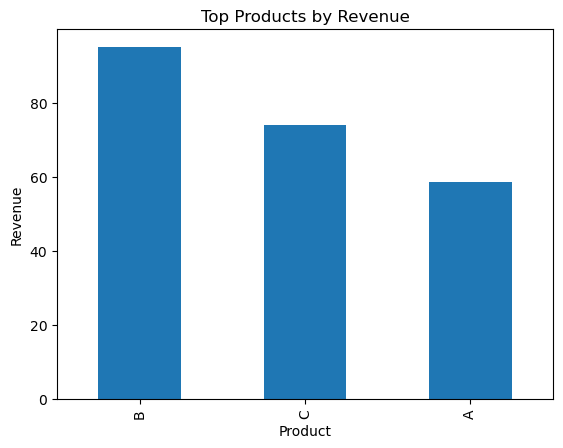

In [220]:
%matplotlib inline
import matplotlib.pyplot as plt
# Simple plot: top products by revenue (from Pandas result)
plt.figure()
df_top_pd.plot(x="product", y="Revenue", kind="bar", legend=False)
plt.title("Top Products by Revenue")
plt.xlabel("Product")
plt.ylabel("Revenue")
plt.show()



<a id="integration"></a>

### Integration Project: E-commerce Sales Analytics

**Flow:** Database → Pandas → EDA → NumPy  
- Query transactions  
- Clean & feature engineering (`Revenue`)  
- EDA (distribution, trend, Pareto)  
- NumPy normalization & covariance


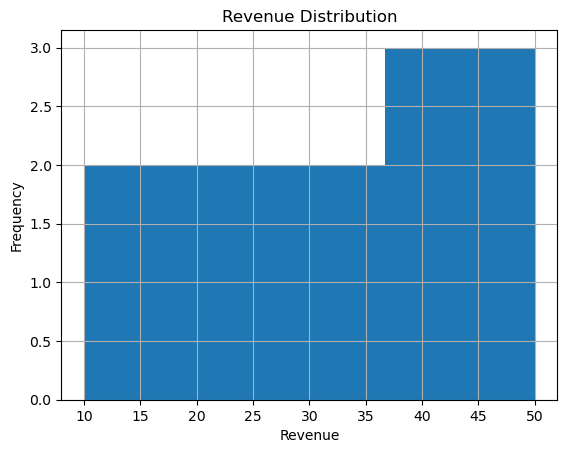

In [221]:
%matplotlib inline
# Query from SQLite (replace with MySQL connection in your environment)
df = pd.read_sql_query("SELECT product, quantity, price, discount, date FROM transactions", conn)
df["date"] = pd.to_datetime(df["date"])
df["Revenue"] = df["quantity"] * df["price"] * (1 - df["discount"])

# EDA: distribution
plt.figure()
df["Revenue"].hist(bins=3)
plt.title("Revenue Distribution")
plt.xlabel("Revenue")
plt.ylabel("Frequency")
plt.show()



In [222]:

import numpy as np
# NumPy: normalization & covariance on selected features
arr = df[["quantity","price","Revenue"]].to_numpy(dtype=float)
# avoid divide-by-zero
norms = np.linalg.norm(arr, axis=0, keepdims=True)
norms[norms==0] = 1.0
arr_norm = arr / norms
cov = np.cov(arr_norm.T)

print("Normalized (first 5 rows):\n", arr_norm[:5])
print("\nCovariance matrix:\n", cov)


Normalized (first 5 rows):
 [[0.20412415 0.14509525 0.10787512]
 [0.40824829 0.36273813 0.48543802]
 [0.61237244 0.14509525 0.30744408]
 [0.20412415 0.580381   0.43150046]
 [0.40824829 0.36273813 0.53937558]]

Covariance matrix:
 [[ 0.02380952 -0.01692425  0.00348649]
 [-0.01692425  0.03834586  0.0187826 ]
 [ 0.00348649  0.0187826   0.02326438]]



<a id="eda-manual"></a>

### EDA (Manual -Pandas + Matplotlib)

**Goals:**  
- Explore distributions, categories, correlations, outliers, and trends.


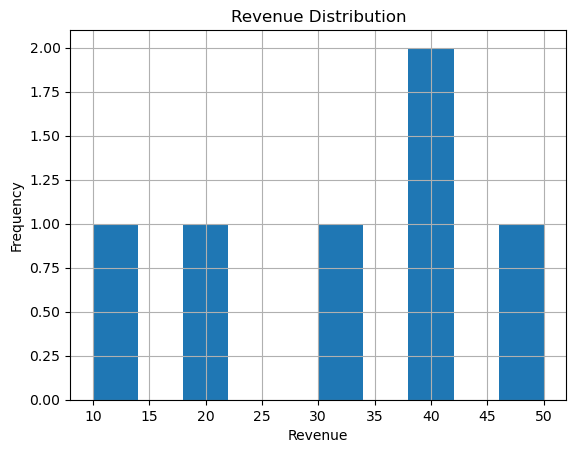

In [223]:
%matplotlib inline
# Distribution: histogram of revenue
plt.figure()
orders["revenue"].hist(bins=10)
plt.title("Revenue Distribution")
plt.xlabel("Revenue")
plt.ylabel("Frequency")
plt.show()


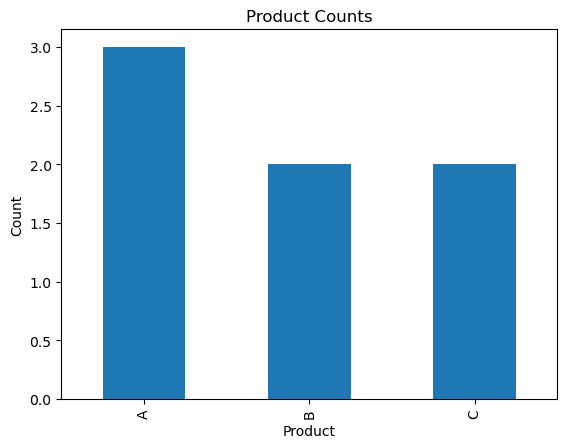

In [224]:
%matplotlib inline
# Categorical: product counts
plt.figure()
orders["product"].value_counts().plot(kind="bar")
plt.title("Product Counts")
plt.xlabel("Product")
plt.ylabel("Count")
plt.show()


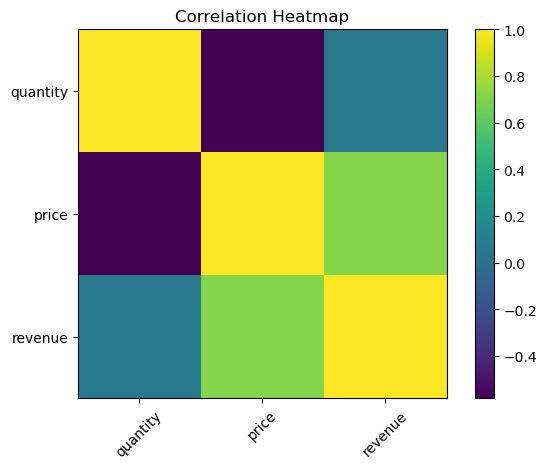

In [225]:
%matplotlib inline
# Correlation heatmap
corr = orders[["quantity","price","revenue"]].corr(numeric_only=True)
plt.figure()
plt.imshow(corr, interpolation='nearest')
plt.xticks(range(len(corr)), corr.columns, rotation=45)
plt.yticks(range(len(corr)), corr.columns)
plt.colorbar()
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()


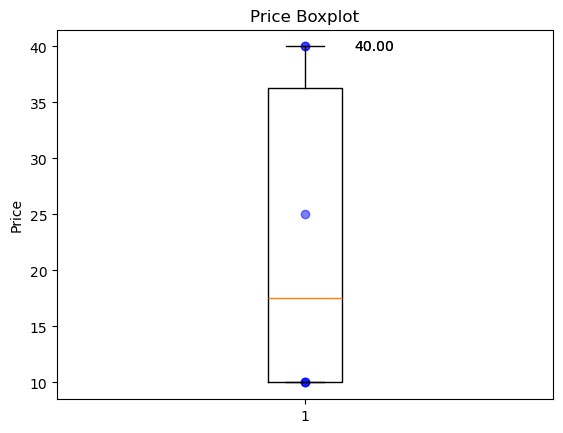

In [226]:
%matplotlib inline
# Outliers: boxplot of price
plt.figure()
plt.boxplot(orders["price"].dropna(), vert=True)
plt.title("Price Boxplot")
plt.ylabel("Price")
for i, price in enumerate(orders["price"]):
    # show all data points
    plt.scatter(1, price, color='blue', alpha=0.5)
    if price > 30:  # arbitrary threshold for outlier
        plt.text(1.1, price, f"{price:.2f}", va='center')   
plt.show()


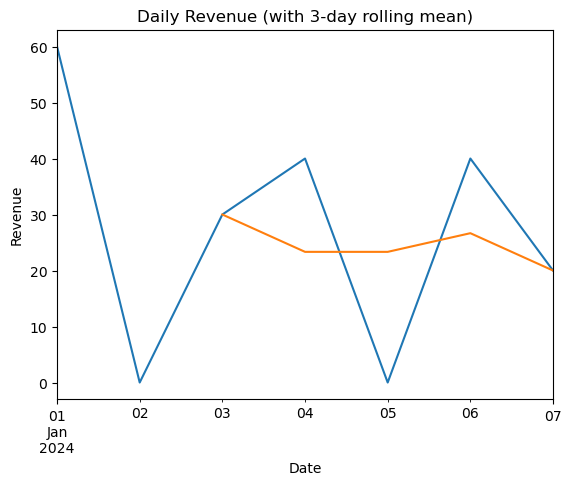

In [227]:
%matplotlib inline
# Trend: daily revenue + rolling mean
plt.figure()
# reminder:
#    Time series resample (sum revenue by day, then 3-day rolling mean)
#    ts = orders.set_index("date")["revenue"].resample("D").sum()
ts.plot()
ts.rolling(3).mean().plot()
plt.title("Daily Revenue (with 3-day rolling mean)")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.show()


### Plots

#### matplotlib 

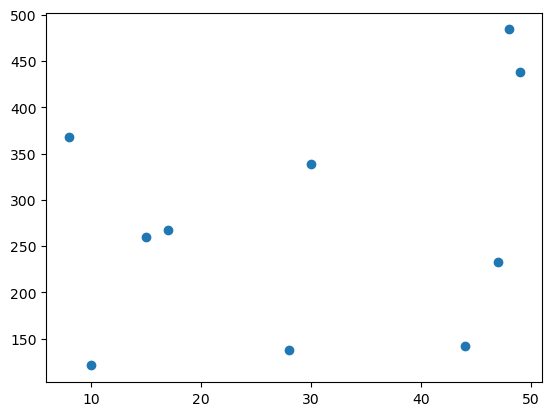

In [228]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import random
x = np.array(random.sample(range(1, 50), 10))
y = np.array(random.sample(range(100, 500), 10))

plt.scatter(x, y)
plt.show()

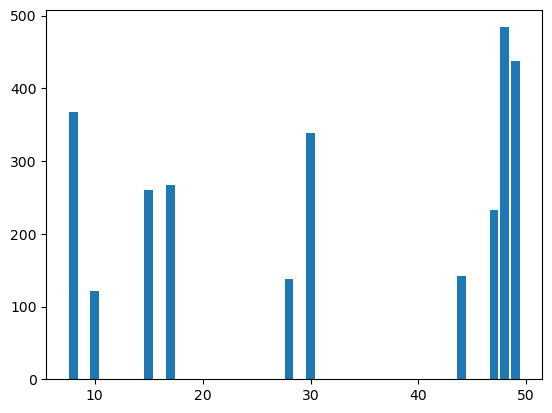

In [229]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import random


plt.bar(x, y)
plt.show()

#### Plotly 

In [230]:
#!pip install plotly[express]

In [231]:
import plotly.express as px
import random
x = np.array(random.sample(range(1, 50), 10))
y = np.array(random.sample(range(100, 500), 10))
fig = px.scatter(x=x, y=y)
fig.show()

In [232]:
import plotly.express as px
x = np.array(random.sample(range(1, 50), 10))
y = np.array(random.sample(range(100, 500), 10))
fig = px.bar(x=x, y=y)
fig.show()

#### Pandas Plots

### Diamond Prices Explorative data analysis
Data source: https://www.kaggle.com/shivam2503/diamonds


Context
This classic dataset contains the prices and other attributes of almost 54,000 diamonds. It's a great dataset for beginners learning to work with data analysis and visualization.

Content
- **price**   price in US dollars (\$326--\$18,823)
- **carat**   weight of the diamond (0.2--5.01)
- **cut**     quality of the cut (Fair, Good, Very Good, Premium, Ideal)
- **color**   diamond colour, from J (worst) to D (best)
- **clarity** a measurement of how clear the diamond is (I1 (worst), SI2, SI1, VS2, VS1, VVS2, VVS1, IF (best))
- **x**       length in mm (0--10.74)
- **y**       width in mm (0--58.9)
- **z**       depth in mm (0--31.8)
- **depth**   total depth percentage = z / mean(x, y) = 2 * z / (x + y) (43--79)
- **table**   width of top of diamond relative to widest point (43--95)

In [233]:
import kagglehub
import pandas as pd
import os
import zipfile
import shutil

def load_diamonds_dataset():
    # Ensure local_data exists
    os.makedirs("local_data", exist_ok=True)

    # Download latest version via kagglehub
    path = kagglehub.dataset_download("shivam2503/diamonds")
    print("Downloaded dataset path:", path)

    # Path to save the zip
    zip_path = "local_data/diamonds.zip"

    # Create a zip file from the dataset folder
    shutil.make_archive("local_data/diamonds", 'zip', path)

    print(f"Dataset compressed into: {zip_path}")

    # Read CSV directly from zip
    data = pd.read_csv(zip_path, index_col=0, compression="zip")
    print(f"Loaded {data.shape[0]}x{data.shape[1]} dataset")

    return data

# Example usage
data = load_diamonds_dataset()
print(data.head())


Downloaded dataset path: C:\Users\קונפינו\.cache\kagglehub\datasets\shivam2503\diamonds\versions\1
Dataset compressed into: local_data/diamonds.zip
Loaded 53940x10 dataset
   carat      cut color clarity  depth  table  price     x     y     z
1   0.23    Ideal     E     SI2   61.5   55.0    326  3.95  3.98  2.43
2   0.21  Premium     E     SI1   59.8   61.0    326  3.89  3.84  2.31
3   0.23     Good     E     VS1   56.9   65.0    327  4.05  4.07  2.31
4   0.29  Premium     I     VS2   62.4   58.0    334  4.20  4.23  2.63
5   0.31     Good     J     SI2   63.3   58.0    335  4.34  4.35  2.75


#### Data Exploration size vs. price



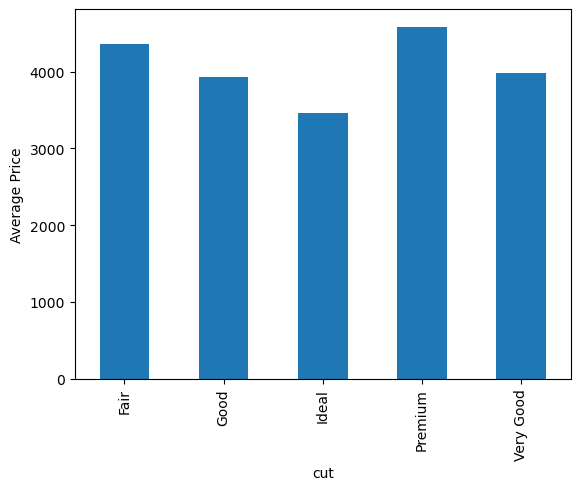

"\n# Restoring the order in Pandas\nfrom pandas.api.types import CategoricalDtype\n\ncut_order = CategoricalDtype(\n    categories=['Fair', 'Good', 'Very Good', 'Premium', 'Ideal'], \n    ordered=True\n)\ndf['cut'] = df['cut'].astype(cut_order)\n"

In [234]:
import pandas as pd
import matplotlib.pyplot as plt
agg = data.groupby('cut')['price'].mean()

ax = agg.plot(kind='bar')   # now only one bar per unique 'cut'. note the order of the bars is not the same as is described in the metadata.
ax.set_ylabel('Average Price')
plt.show()

# to sort the bars use:
'''
# Restoring the order in Pandas
from pandas.api.types import CategoricalDtype

cut_order = CategoricalDtype(
    categories=['Fair', 'Good', 'Very Good', 'Premium', 'Ideal'], 
    ordered=True
)
df['cut'] = df['cut'].astype(cut_order)
'''

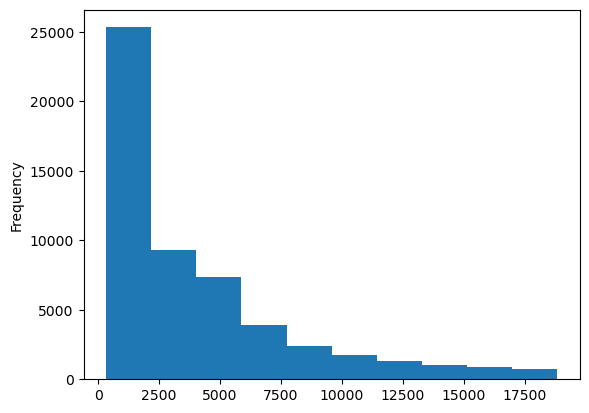

In [235]:
data['price'].plot(kind = 'hist')
plt.show() 

In [236]:
#load the data
data = pd.read_csv('local_data/diamonds.zip', index_col=0)
print(f"Loaded {data.shape[0]}x{data.shape[1]}")
data.head()

Loaded 53940x10


,carat,cut,color,clarity,depth,table,price,x,y,z
1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


#### Data Exploration size vs. price
##### Scatter plot
<img src="local_data/scatter_plots.png">

In [237]:
%matplotlib inline
def plot_2vars(x, y):
    import pandas as pd
    import matplotlib.pyplot as plt
    
    data = pd.DataFrame({'x': x, 'y': y})
    ax = data.plot.scatter(x='x', y='y', s=1, label=f"{data['x'].corr(data['y']):2.2f}", figsize=(12, 9))
    ax.legend()
    ax.set_xlabel('parameter 1')
    ax.set_ylabel('parameter 2')
    plt.show()  # <- this line shows the plot if you're in a script
    return ax

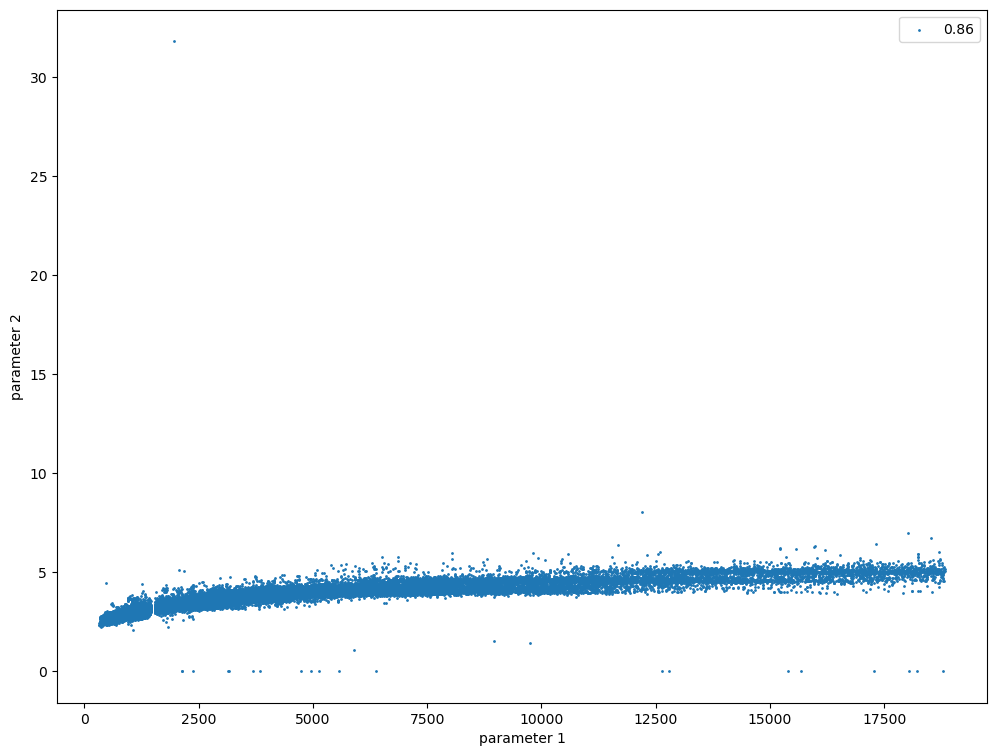

<Axes: xlabel='parameter 1', ylabel='parameter 2'>

In [238]:
plot_2vars(data['price'].values,data['z'])

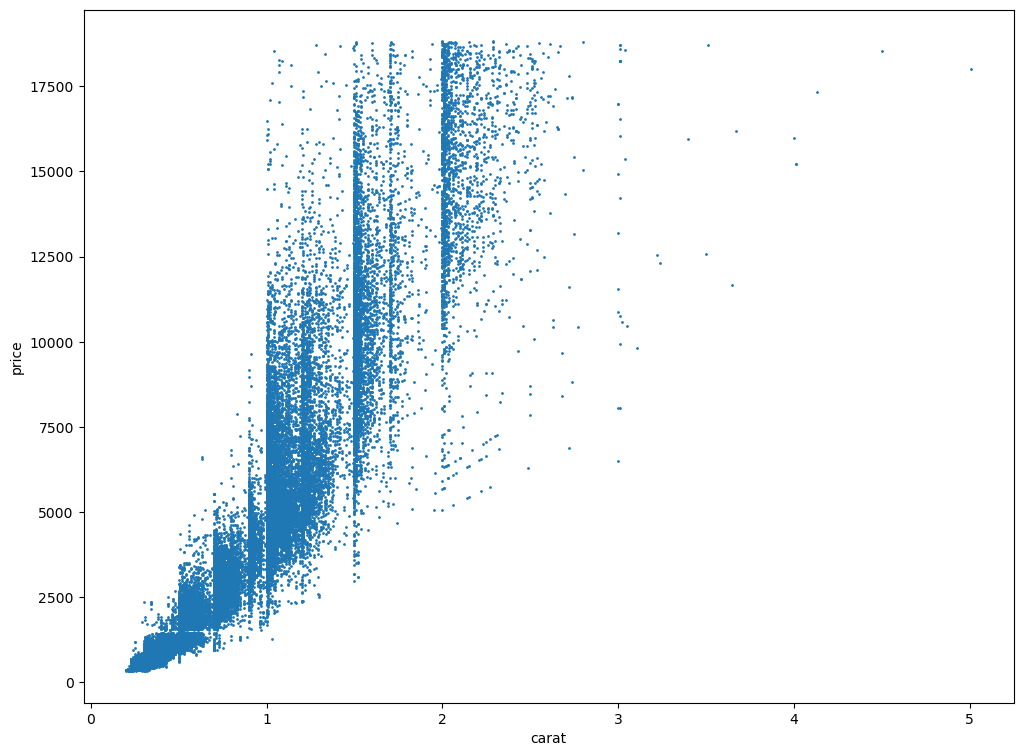

In [239]:
ax = data.plot.scatter(x='carat',y='price',s=1, figsize=(12,9))
plt.show() 

#### Correlation
pearson correlation coefficient
$corr(X,Y)=\dfrac{1}{N}\sum_{i=1}^{N}{\dfrac{(x-{\mu}_x)}{{\sigma}_x}*\dfrac{(y-{\mu}_y)}{{\sigma}_y}}$<br>
- ${\mu}_x$ - expected value of the series $X$
- ${\sigma}_x$ - standard deviation, $${\sigma}_x = \sqrt{ \dfrac{1}{N-1}}\sum_{i=1}^{N}{(x_i-\mu_x)^2}$$
- $<...>$ - average

In [240]:
corr_coeff = data['carat'].corr(data['price'])
print(f'Pearson correlation coefficient: size vs. price: {corr_coeff:3.3f}')

Pearson correlation coefficient: size vs. price: 0.922


#### Reveal Functional Form

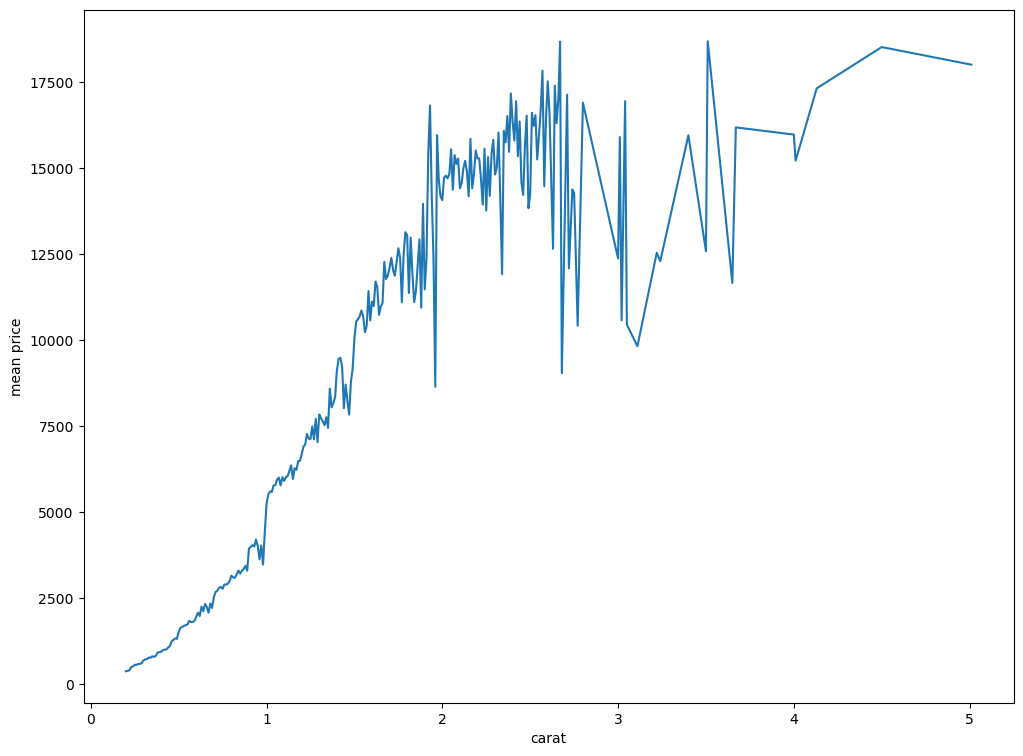

In [241]:
price_mean = data.groupby('carat')['price'].mean()
ax = price_mean.plot(figsize=(12,9))
ax.set_ylabel('mean price')
plt.show() 

Issues:
- missing confidence intervals (std)
- noise in the tail

#### Compute mean and standard error vs standard deviation

- standard deviation, $${\sigma}_x = \sqrt{ \dfrac{1}{N-1}}\sum_{i=1}^{N}{(x_i-\mu_x)^2}$$
Represents how broad the distribution is
- standard error of the mean (SEM): confidence in the estimate of the mean. 
$SEM(x)=\dfrac{\sigma_x}{\sqrt{N}}$
assumes independence of the values in your sample


In [242]:
price_mean.head()

carat
0.20    365.166667
0.21    380.222222
0.22    391.400000
0.23    486.143345
0.24    505.185039
Name: price, dtype: float64

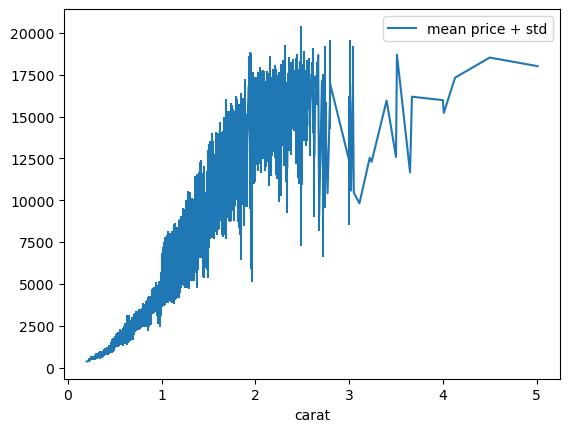

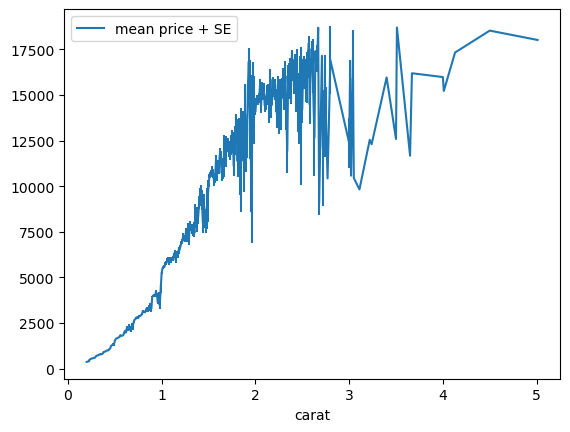

In [243]:
def SEM(x): # standard error of the mean
    import math  
    if math.sqrt(len(x))==0:
        return 0
    return x.std()/math.sqrt(len(x))

price_mean = data.groupby('carat').agg({'price':['mean', 'std', SEM]})

price_mean.plot(y=('price','mean'),yerr=price_mean[('price','std')], label='mean price + std');

price_mean.plot(y=('price','mean'),yerr=price_mean[('price','SEM')], label='mean price + SE');
plt.show() 


#### Bin data 

##### Binning data linearly helps, but there's still noise in the tail

C:\Users\קונפינו\AppData\Local\Temp\ipykernel_31880\1816191840.py:2: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



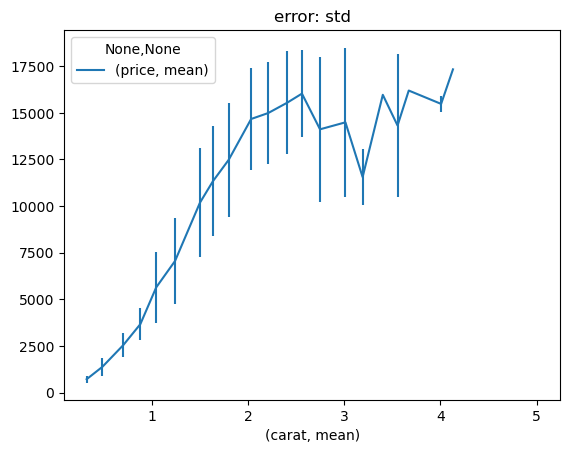

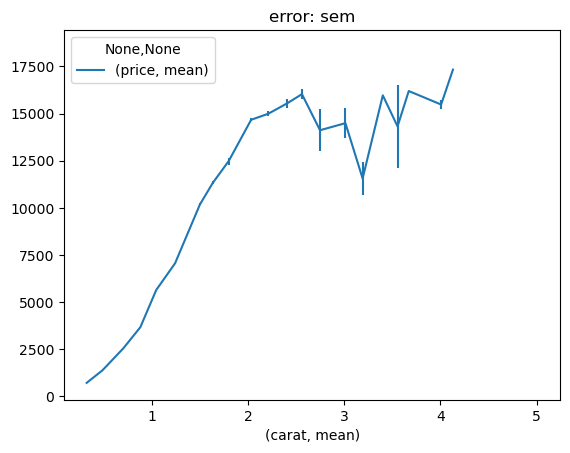

In [244]:
categories, bins = pd.cut(data['carat'], bins=25, retbins=True)
price_mean = data.groupby(categories, as_index=True).agg({'price':['mean', 'std', SEM], 'carat': 'mean'})
ax = price_mean.plot(x=('carat', 'mean'),y=('price','mean'),yerr=price_mean[('price','std')].values);
ax.set_title('error: std')
ax = price_mean.plot(x=('carat', 'mean'), y=('price','mean'),yerr=price_mean[('price','SEM')].values);
ax.set_title('error: sem')
plt.show() 

##### diamond size distribution: very uneven 

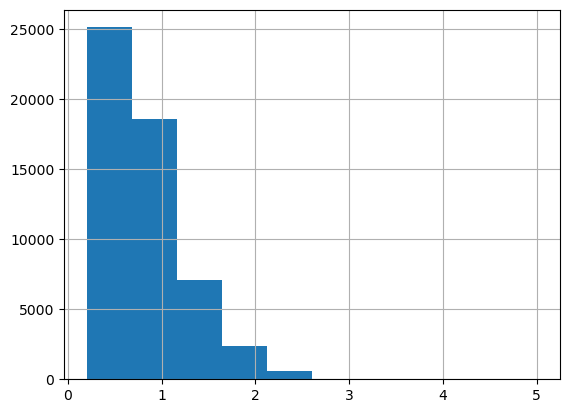

In [245]:
ax = data['carat'].hist()
plt.show() 

##### bin using equally-populated bins. 
- <code>qcut</code>:    Quantile-based discretization function.

C:\Users\קונפינו\AppData\Local\Temp\ipykernel_31880\1691348841.py:2: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



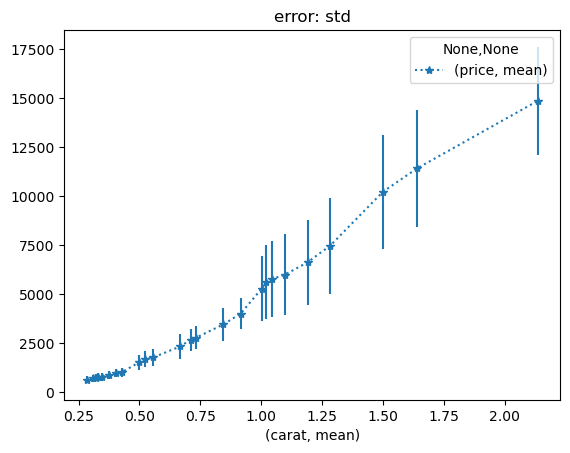

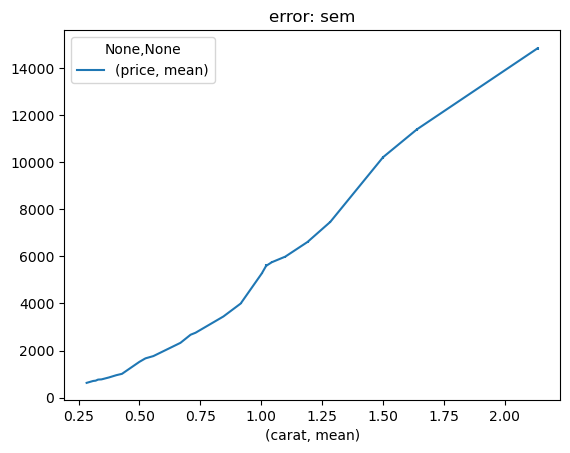

In [246]:
categories, bins = pd.qcut(data['carat'], q=25, retbins=True)
price_mean = data.groupby(categories, as_index=True).agg({'price':['mean', 'std', SEM], 'carat': 'mean'})
ax = price_mean.plot(x=('carat', 'mean'),y=('price','mean'),yerr=price_mean[('price','std')].values, linestyle=':', marker='*');
ax.set_title('error: std')
ax = price_mean.plot(x=('carat', 'mean'), y=('price','mean'),yerr=price_mean[('price','SEM')].values);
ax.set_title('error: sem')
plt.show() 

In [247]:
corr_matrix = data.corr(numeric_only=True)
print(corr_matrix)

          carat     depth     table     price         x         y         z
carat  1.000000  0.028224  0.181618  0.921591  0.975094  0.951722  0.953387
depth  0.028224  1.000000 -0.295779 -0.010647 -0.025289 -0.029341  0.094924
table  0.181618 -0.295779  1.000000  0.127134  0.195344  0.183760  0.150929
price  0.921591 -0.010647  0.127134  1.000000  0.884435  0.865421  0.861249
x      0.975094 -0.025289  0.195344  0.884435  1.000000  0.974701  0.970772
y      0.951722 -0.029341  0.183760  0.865421  0.974701  1.000000  0.952006
z      0.953387  0.094924  0.150929  0.861249  0.970772  0.952006  1.000000


#### Using seaborn

In [248]:
#!pip install seaborn

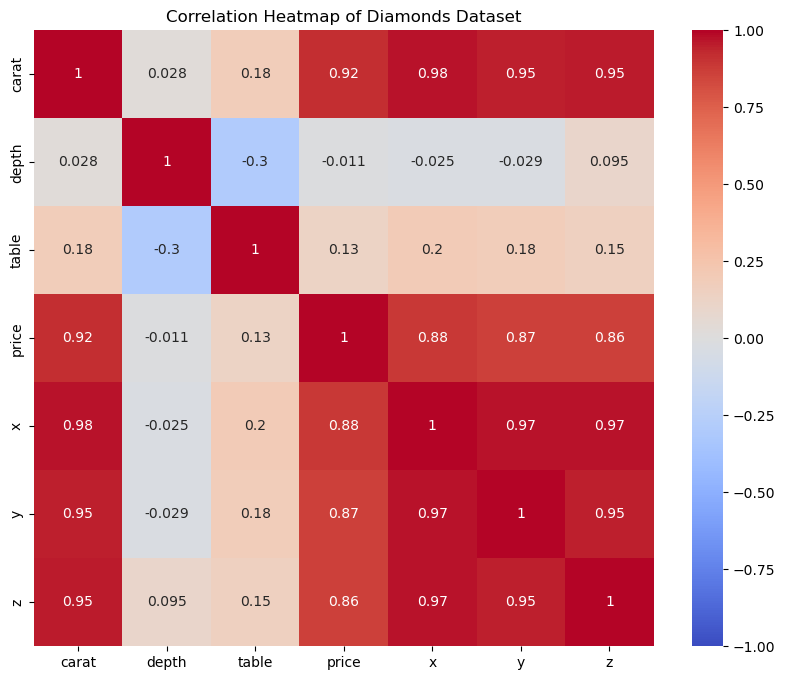

In [249]:
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Heatmap of Diamonds Dataset')
plt.show()


<a id="eda-auto"></a>

### Automatic EDA Tools

> These tools generate fast, comprehensive overviews. Use them for initial insights, then deep-dive manually.

**Packages Covered:**  
- `ydata-profiling` (formerly pandas-profiling)  
- `sweetviz`  
- `dtale`  
- `autoviz`  

> Install if missing:  
> `pip install ydata-profiling sweetviz dtale autoviz`


In [250]:

# ydata-profiling (pandas-profiling) — inline in notebook. 
# need setuptools < 72 to avoid error  : ModuleNotFoundError: No module named 'pkg_resources'

from ydata_profiling import ProfileReport
try:
    from ydata_profiling import ProfileReport
    profile = ProfileReport(pd.DataFrame.from_dict(data), explorative=True, minimal=True)
    # In Jupyter: profile.to_notebook_iframe()
    # As a file (useful for sharing):
    profile.to_file("local_data/dimonds_profiling_report.html")
    print("Saved: dimonds_profiling_report.html")
except Exception as e:
    print("ydata-profiling not available or failed:", e)


ModuleNotFoundError: No module named 'ydata_profiling'

In [ ]:
pd.DataFrame.from_dict(data)

,carat,cut,color,clarity,depth,table,price,x,y,z
1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75
...,...,...,...,...,...,...,...,...,...,...
53936,0.72,Ideal,D,SI1,60.8,57.0,2757,5.75,5.76,3.50
53937,0.72,Good,D,SI1,63.1,55.0,2757,5.69,5.75,3.61
53938,0.70,Very Good,D,SI1,62.8,60.0,2757,5.66,5.68,3.56
53939,0.86,Premium,H,SI2,61.0,58.0,2757,6.15,6.12,3.74


In [ ]:

# Sweetviz — generates an interactive HTML
try:
    import sweetviz as sv
    report = sv.analyze(data)
    report.show_html("local_data/rders_sweetviz_report.html")
    print("Saved: orders_sweetviz_report.html")
except Exception as e:
    print("Sweetviz not available or failed:", e)


                                             |          | [  0%]   00:00 -> (? left)

Report local_data/rders_sweetviz_report.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.
Saved: orders_sweetviz_report.html


In [ ]:

# D-Tale — interactive dataframe explorer (runs a local server)
import dtale
import dash
app = dash.Dash(__name__, eager_loading=True)

import dtale.global_state as global_state
global_state.set_chart_settings({'scatter_points': 15000, '3d_points': 40000})

d = dtale.show(data, ignore_duplicate=True)
d.open_browser()


# print("D-Tale demo commented out for safety in static environments.")


Imported v0.1.905. Please call AutoViz in this sequence:
    AV = AutoViz_Class()
    %matplotlib inline
    dfte = AV.AutoViz(filename, sep=',', depVar='', dfte=None, header=0, verbose=1, lowess=False,
               chart_format='svg',max_rows_analyzed=150000,max_cols_analyzed=30, save_plot_dir=None)
    Since nrows is smaller than dataset, loading random sample of 1500 rows into pandas...
Shape of your Data Set loaded: (1500, 10)
#######################################################################################
######################## C L A S S I F Y I N G  V A R I A B L E S  ####################
#######################################################################################
Classifying variables in data set...
    Number of Numeric Columns =  6
    Number of Integer-Categorical Columns =  1
    Number of String-Categorical Columns =  3
    Number of Factor-Categorical Columns =  0
    Number of String-Boolean Columns =  0
    Number of Numeric-Boolean Columns =  0
   

,Data Type,Missing Values%,Unique Values%,Minimum Value,Maximum Value,DQ Issue
carat,float64,0.000000,NA,0.200000,3.010000,Column has 22 outliers greater than upper bound (2.08) or lower than lower bound(-0.61). Cap them or remove them.
cut,object,0.000000,0,,,No issue
color,object,0.000000,0,,,No issue
clarity,object,0.000000,0,,,No issue
depth,float64,0.000000,NA,56.200000,69.300000,Column has 77 outliers greater than upper bound (64.75) or lower than lower bound(58.75). Cap them or remove them.
table,float64,0.000000,NA,52.000000,68.000000,Column has 15 outliers greater than upper bound (63.50) or lower than lower bound(51.50). Cap them or remove them.
price,int64,0.000000,83,351.000000,18759.000000,"Column has 89 outliers greater than upper bound (12243.38) or lower than lower bound(-5837.62). Cap them or remove them., Column has a high correlation with ['carat', 'x', 'y', 'z']. Consider dropping one of them."
x,float64,0.000000,NA,0.000000,9.380000,"Column has 1 outliers greater than upper bound (9.42) or lower than lower bound(1.89). Cap them or remove them., Column has a high correlation with ['carat']. Consider dropping one of them."
y,float64,0.000000,NA,0.000000,9.310000,"Column has 1 outliers greater than upper bound (9.38) or lower than lower bound(1.94). Cap them or remove them., Column has a high correlation with ['carat', 'x']. Consider dropping one of them."
z,float64,0.000000,NA,0.000000,5.900000,"Column has 3 outliers greater than upper bound (5.78) or lower than lower bound(1.19). Cap them or remove them., Column has a high correlation with ['carat', 'x', 'y']. Consider dropping one of them."


Number of All Scatter Plots = 21


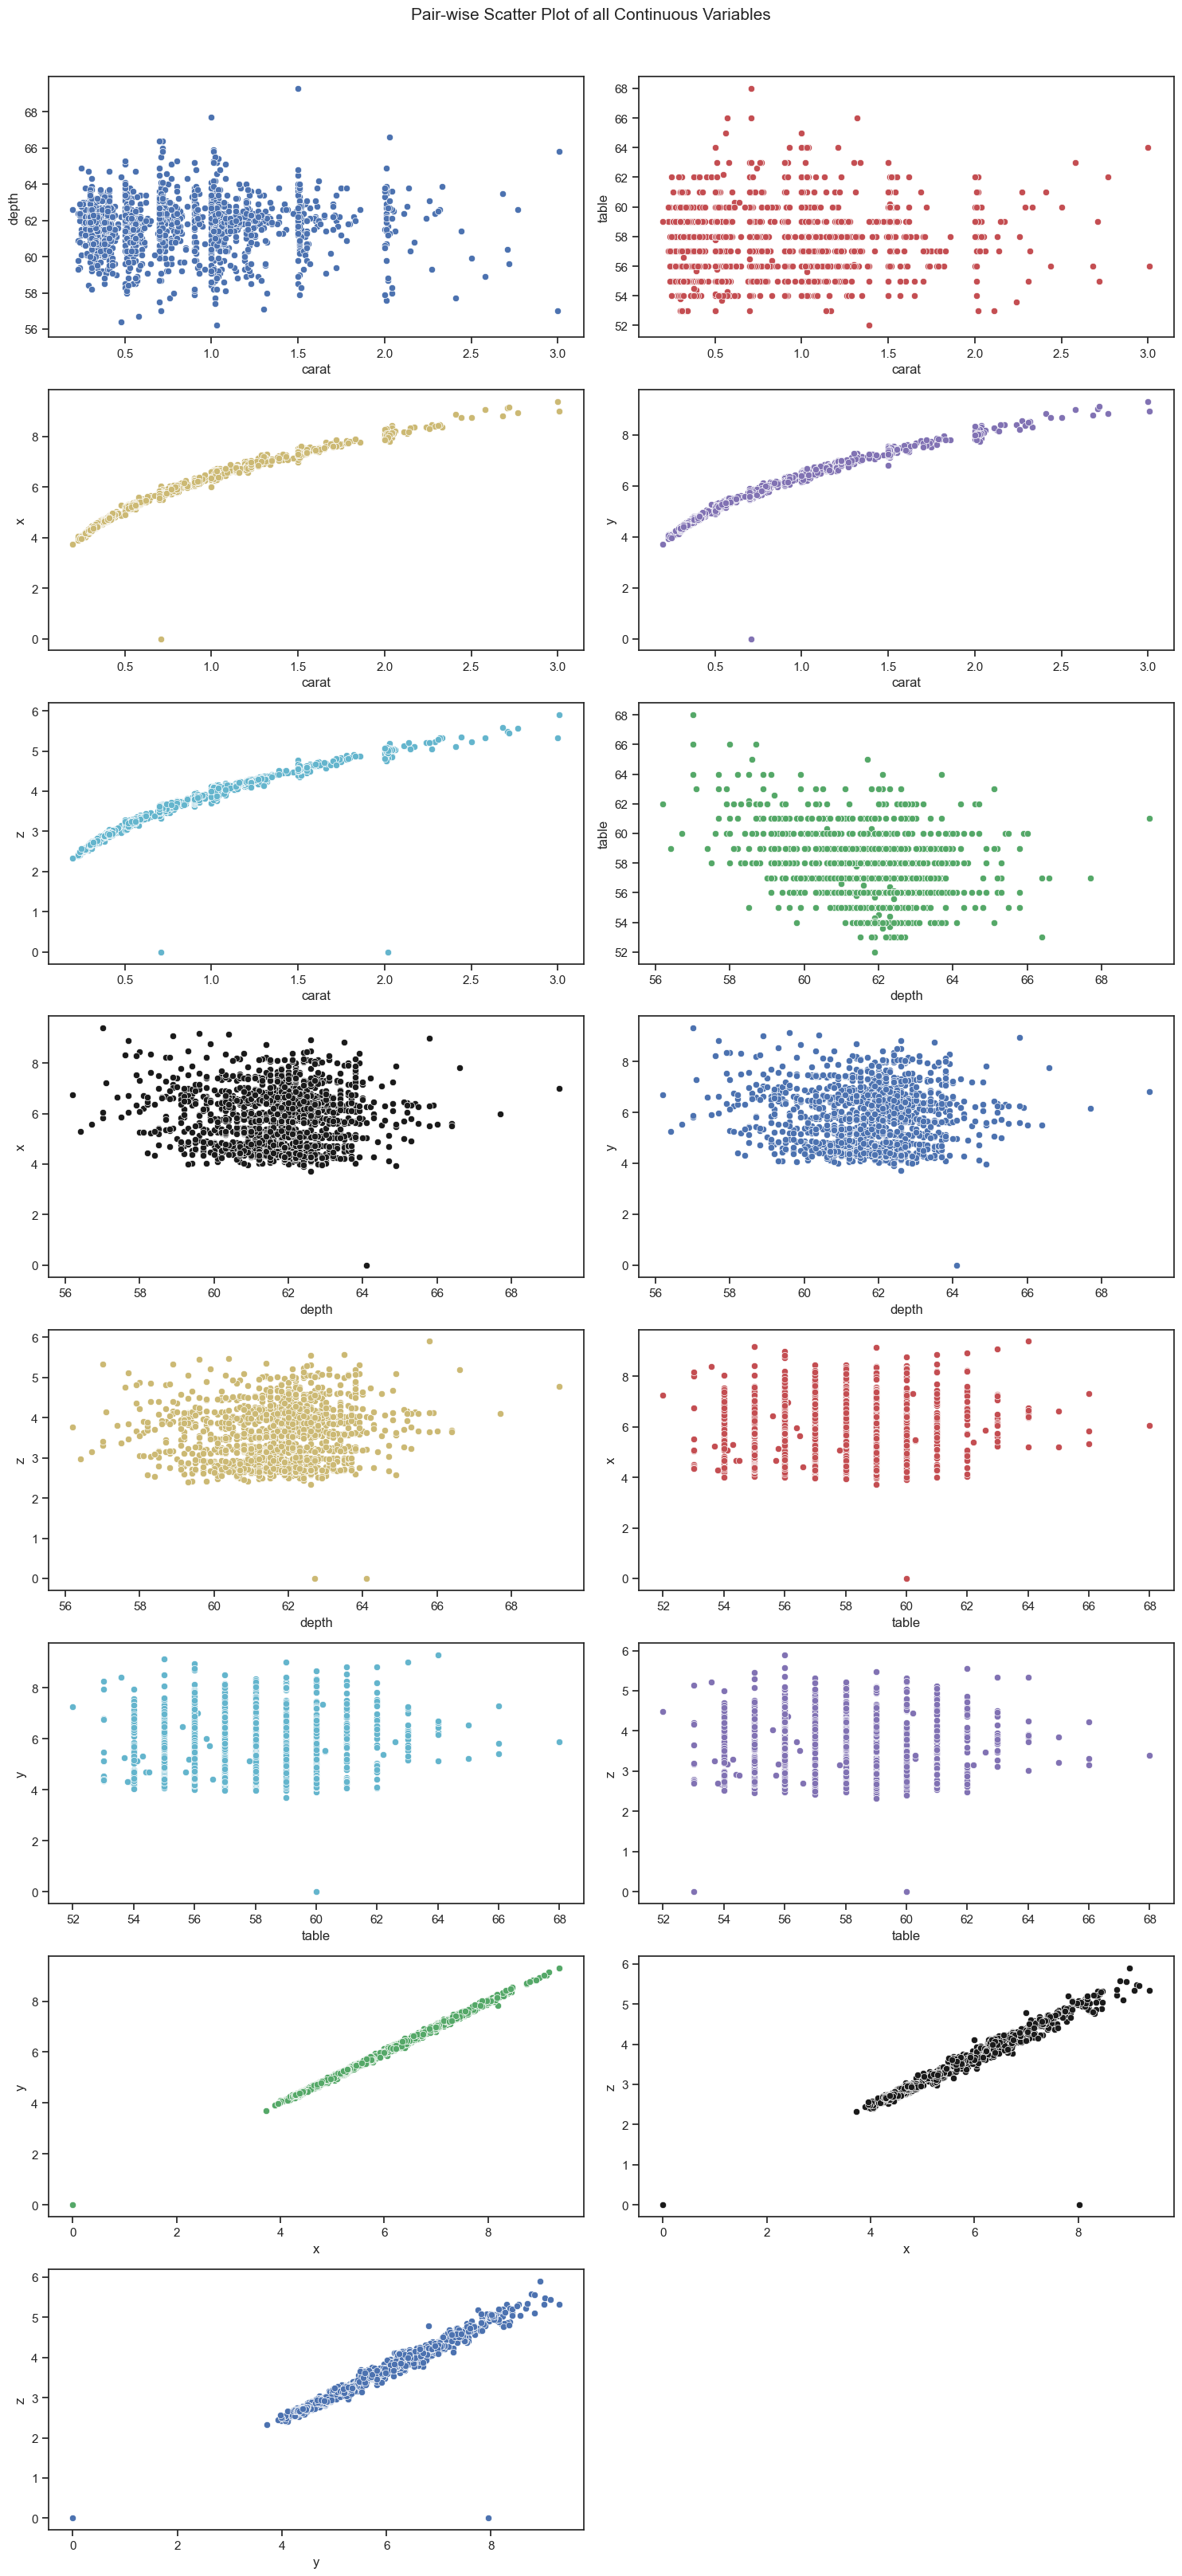

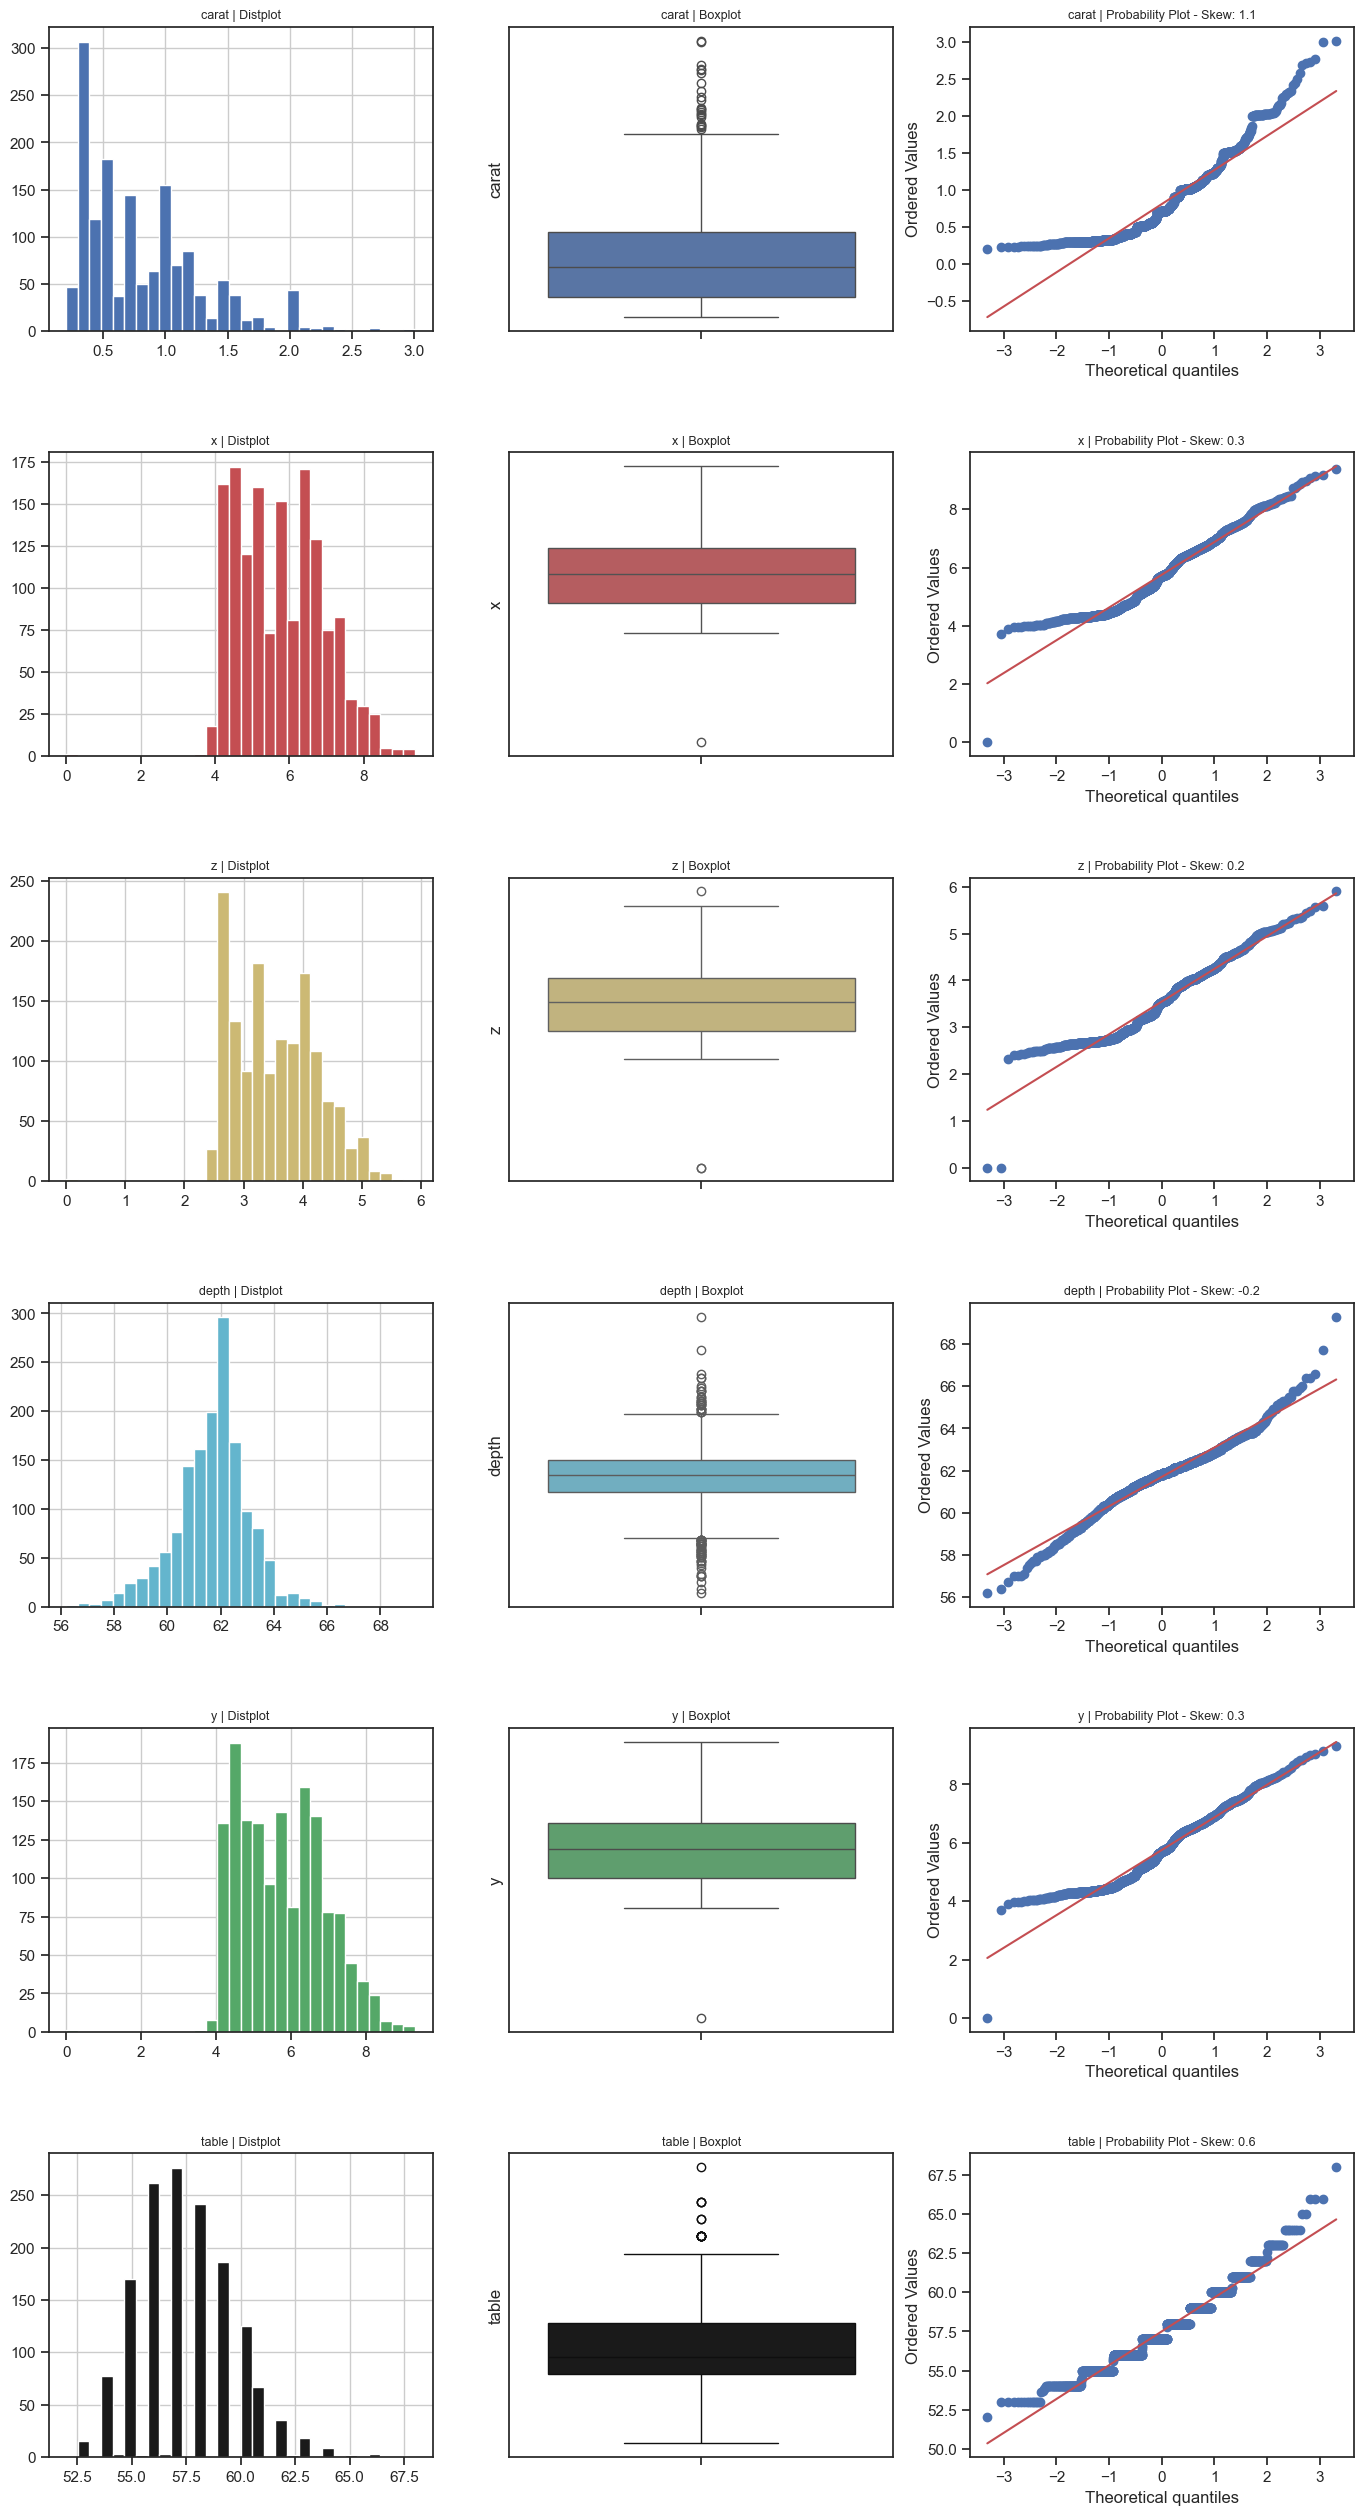

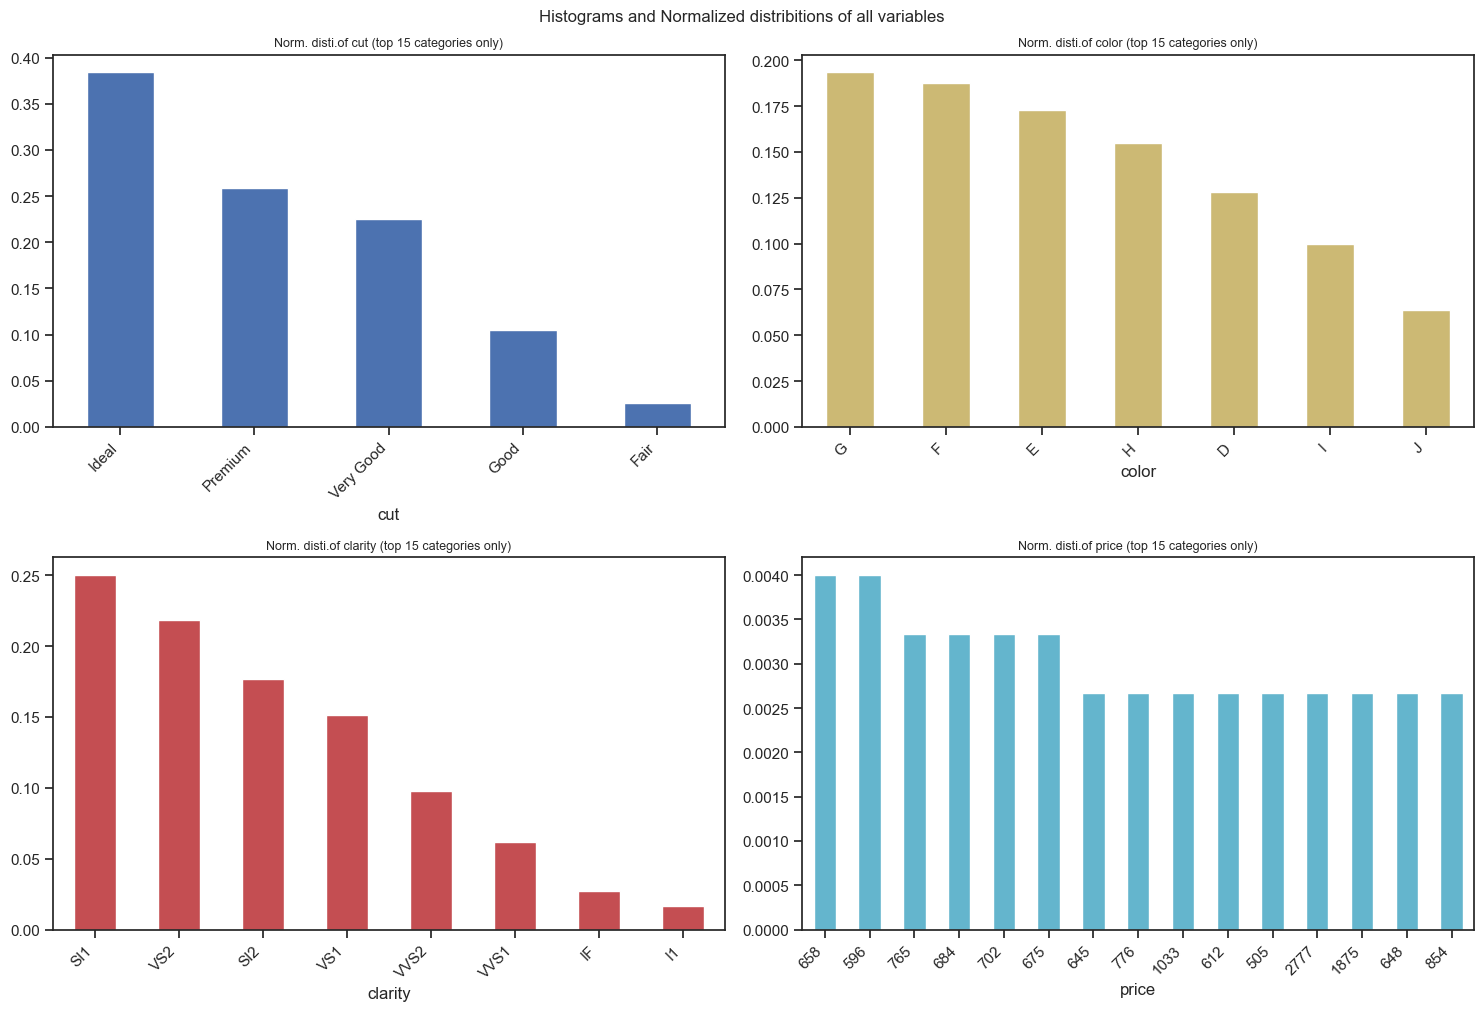

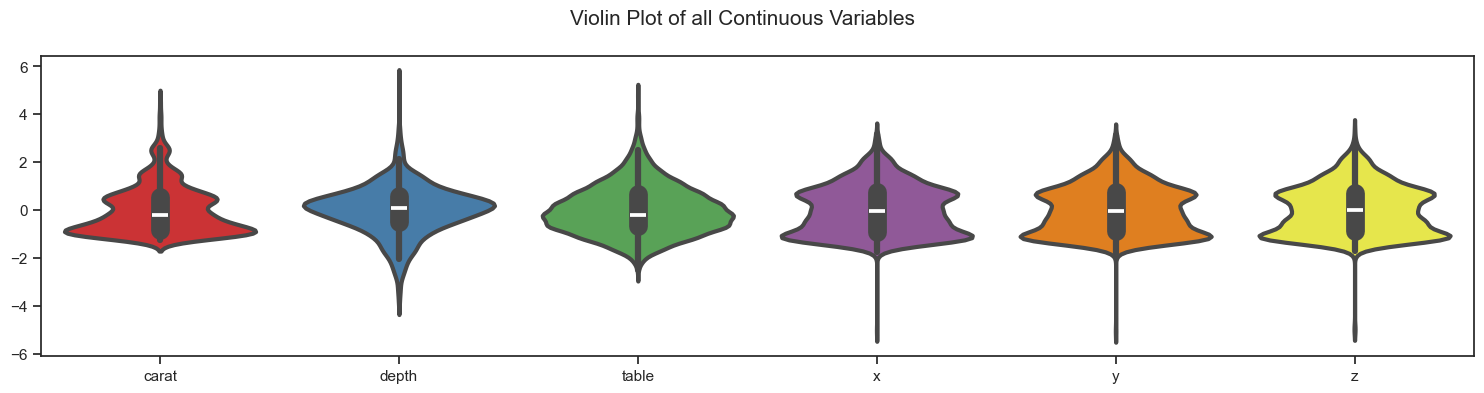

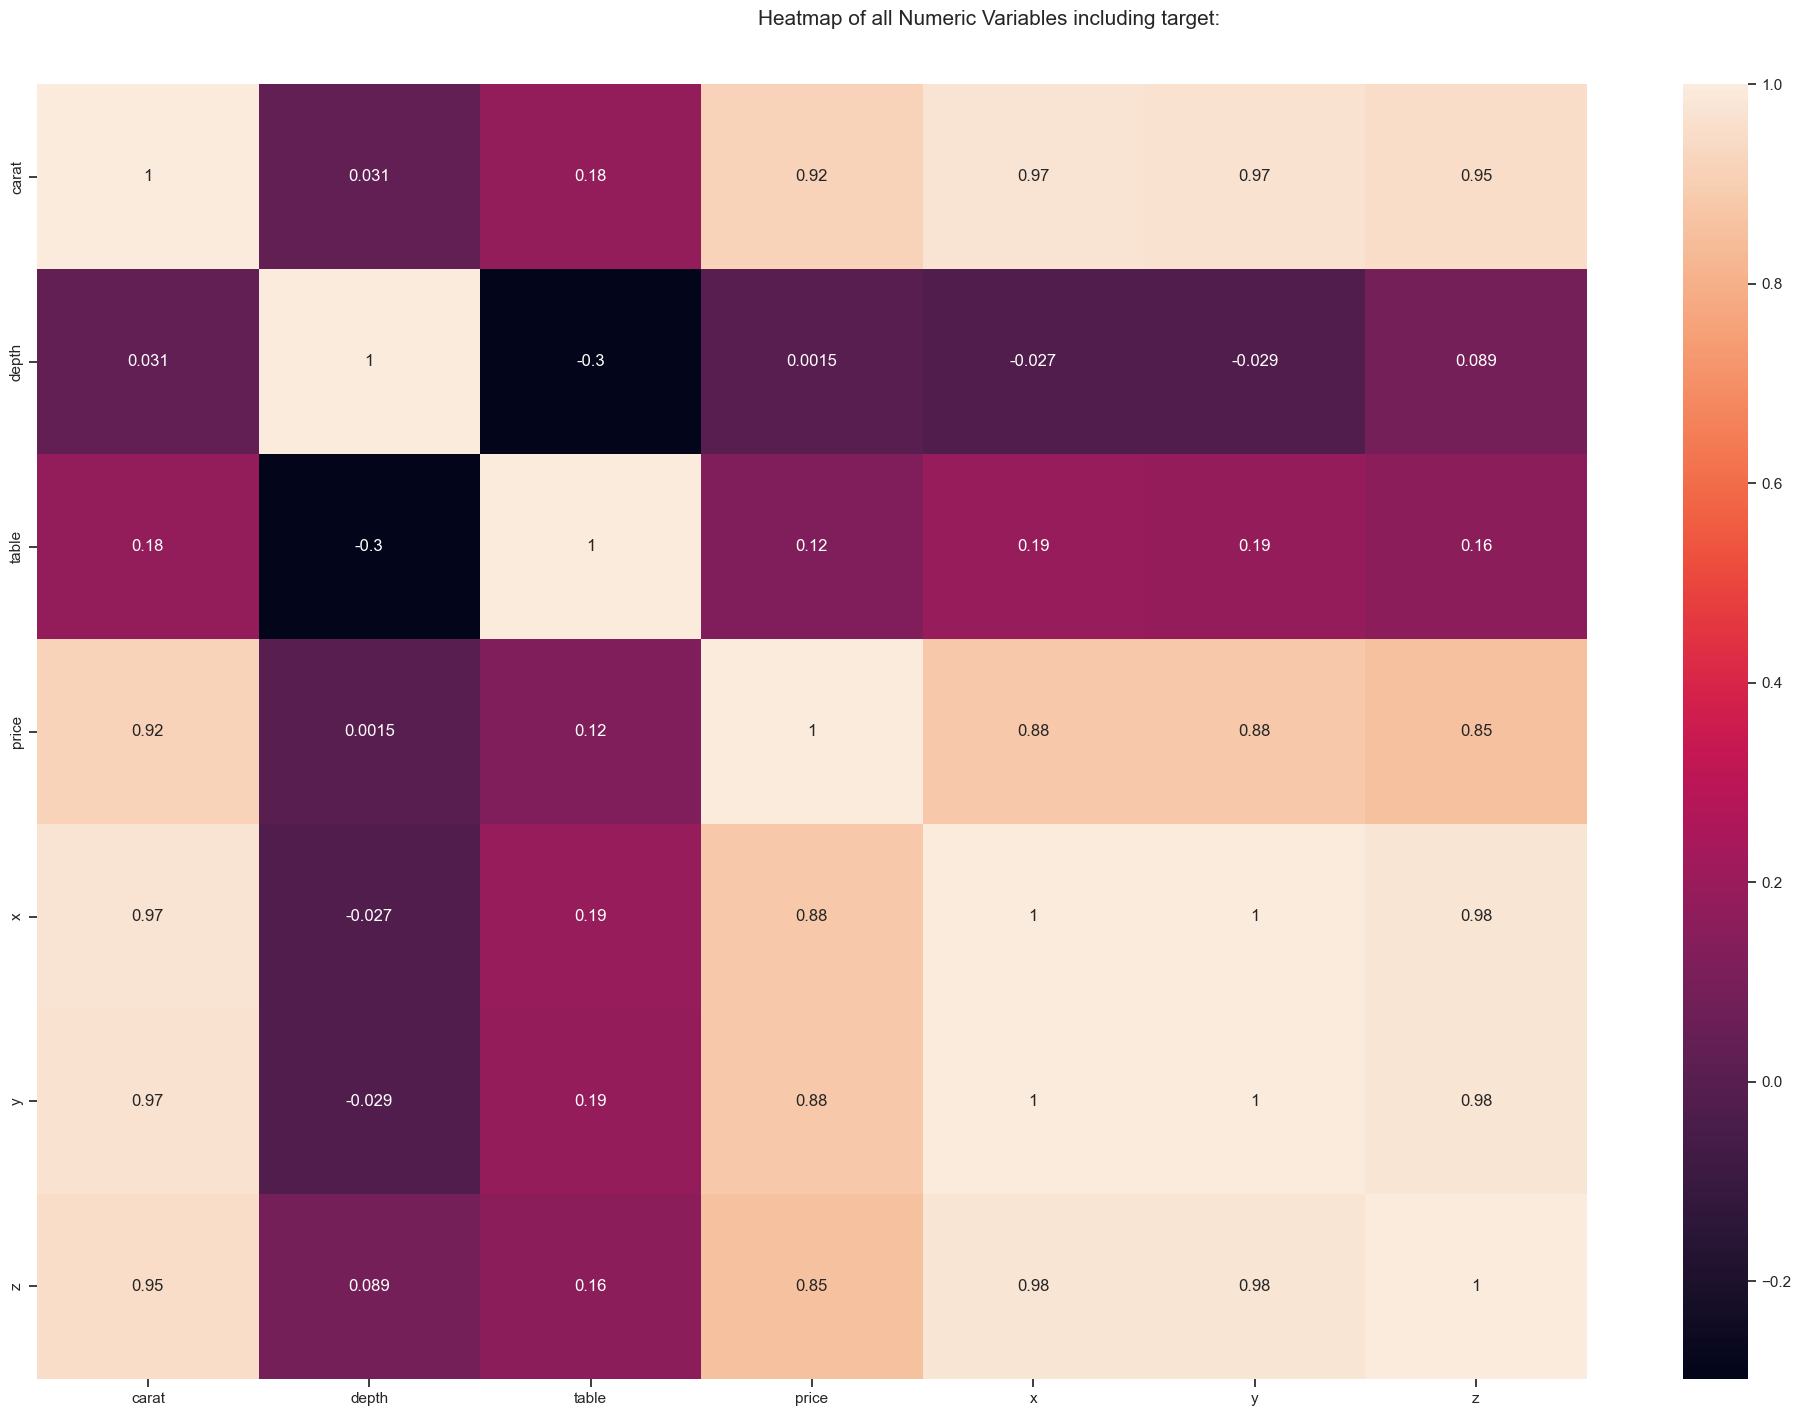

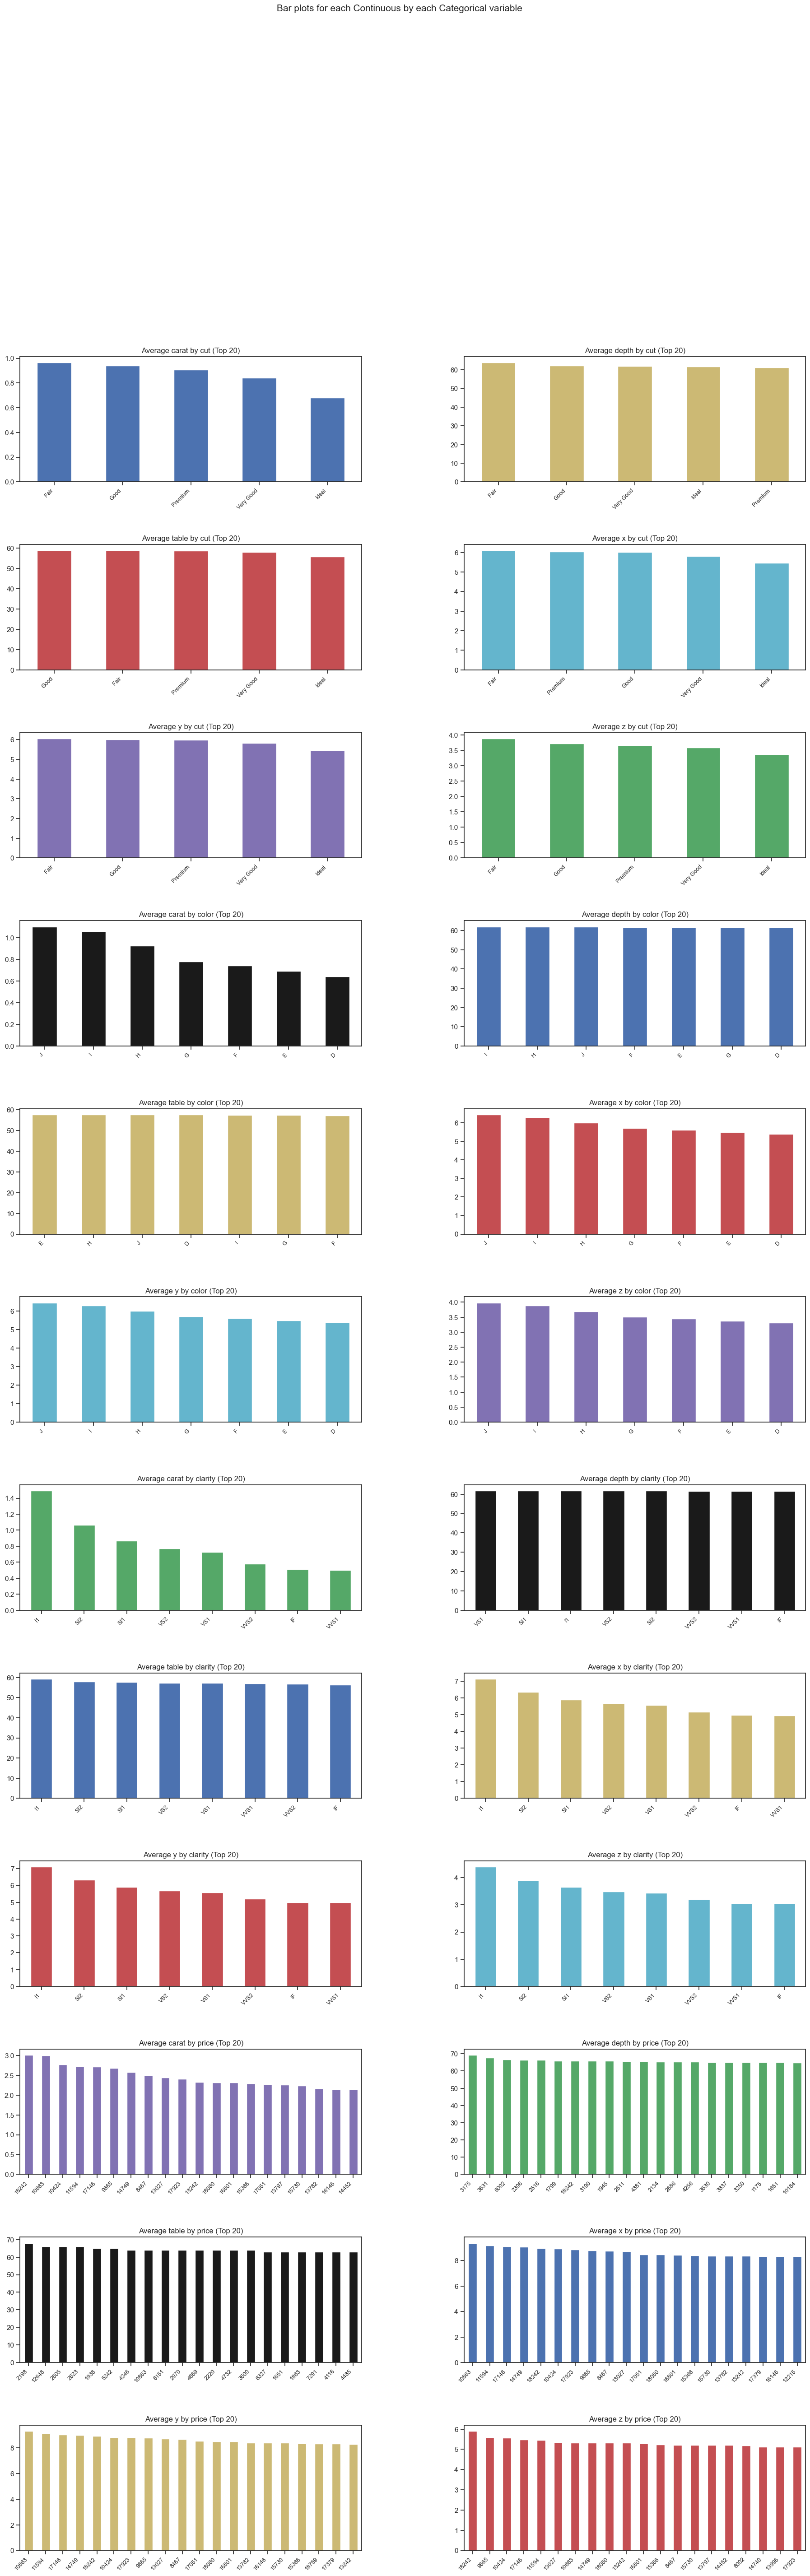

All Plots done
Time to run AutoViz = 11 seconds 

 ###################### AUTO VISUALIZATION Completed ########################
AutoViz run completed (check generated charts above).


In [ ]:

# AutoViz — quick auto visualizations from CSV or DataFrame
try:
    from autoviz.AutoViz_Class import AutoViz_Class
    AV = AutoViz_Class()
    %matplotlib inline
    _ = AV.AutoViz(
        filename="", dfte=data,
        header=0, verbose=1, lowess=False, chart_format="svg",
        max_rows_analyzed=1500, max_cols_analyzed=10,
        save_plot_dir=None
    )
    print("AutoViz run completed (check generated charts above).")
except Exception as e:
    print("AutoViz not available or failed:", e)



<a id="wrapup"></a>

## Wrap-up

- **MySQL/SQL** → where structured data lives.  
- **Pandas** → wrangling, analytics, and **manual EDA**.  
- **NumPy** → numerical backbone for fast math and matrix ops.  
- **Automatic EDA tools** → accelerators for first insights.  
- Together: Database → Pandas → EDA → NumPy → Modeling.
